In [1]:
## TO RUN ON THE CLOUD 

## preprocessed the data before starting the slide
## import embeddings <s
import os

# Define the URI to point to your manual process
os.environ["FIFTYONE_DATABASE_URI"] = "mongodb://localhost:44123"

import fiftyone as fo

# Verify connection
print(fo.core.odm.database.get_db_conn()) 


You are running the oldest supported major version of MongoDB. Please refer to https://deprecation.voxel51.com for deprecation notices. You can suppress this exception by setting your `database_validation` config parameter to `False`. See https://docs.voxel51.com/user_guide/config.html#configuring-a-mongodb-connection for more information
Database(MongoClient(host=['localhost:44123'], document_class=dict, tz_aware=False, connect=True, appname='fiftyone'), 'fiftyone')


In [2]:
fo.list_datasets()

['FLPLAN',
 'UM_teste',
 'WPonly_1024ov224',
 'flplan200',
 'flplanpatches',
 'nc765',
 'nc765_T1024ov224',
 'nc765_T2048ov224',
 'tiles2048_merged',
 'tiles_merged',
 'tiles_merged_2048',
 'train_nc_wp_T1024ov224',
 'umflplan_T1024ov224',
 'umflplan_T2048ov224',
 'wp125',
 'wp125_T1024ov224',
 'wp125_T2048ov224',
 'wp_final_test']

In [3]:
dataset = fo.load_dataset('wp_final_test')

# join json

In [47]:
import json

with open("/share/home/e2406743/code/Dugongs_IRISA-MARBEC-LIRMM/chapter3/json_ids_training/seed1/train_1_merged.json") as f:
    a = json.load(f)

with open("/share/home/e2406743/code/Dugongs_IRISA-MARBEC-LIRMM/chapter3/json_ids_training/seed2/train_2_merged.json") as f:
    b = json.load(f)

with open("/share/home/e2406743/code/Dugongs_IRISA-MARBEC-LIRMM/chapter3/json_ids_training/seed3/train_3_MERGED.json") as f:
    c = json.load(f)

In [58]:
with open("/share/home/e2406743/code/Dugongs_IRISA-MARBEC-LIRMM/chapter3/json_ids_training/p100_all_seeds.json") as f:
    p100 = json.load(f)

In [65]:
p100['1']["train"]["p100"].keys()

dict_keys(['random'])

In [66]:

for seed in merged:
    merged[seed]["train"]["p100"] = {}
    merged[seed]["train"]["p100"]["random"] = p100[seed]["train"]["p100"]["random"]

In [68]:
new_file = "/share/home/e2406743/code/Dugongs_IRISA-MARBEC-LIRMM/chapter3/json_ids_training/MERGED_MERGED.json"
with open(new_file,"w") as f:
    json.dump(merged, f, indent=2)

In [ ]:
import json

print(json.dumps(merged, indent=2))

In [54]:
merged = {}

for d in (a, b, c):
    merged.update(d)

In [55]:
merged.keys()

dict_keys(['1', '2', '3'])

In [57]:
merged['1']['train'].keys()

dict_keys(['p5', 'p10', 'p25', 'p40', 'p50', 'p75'])

In [ ]:
import json
with open("/share/home/e2406743/code/Dugongs_IRISA-MARBEC-LIRMM/chapter3/json_ids_training/MERGED_MERGED.json") as f:
    merged = json.load(f)

In [3]:
dataset = fo.load_dataset("wp_final_test")

# Baseline Evaluation

In [17]:
import json 

def center_to_topleft(box):
    """
    Converts a normalized bounding box from
    [cx, cy, w, h] -> [x, y, w, h]
    """
    cx, cy, w, h = box

    x = max(0.0, cx - w / 2)
    y = max(0.0, cy - h / 2)

    # Clip width/height so boxes stay inside the image
    w = min(w, 1.0 - x)
    h = min(h, 1.0 - y)

    return [x, y, w, h]


def load_predictions_from_json(
    dataset,
    json_path,
    pred_field="predictions",
    overwrite=True,
):
    """
    Loads RT-DETR predictions from a JSON file into a FiftyOne dataset.

    Parameters
    ----------
    dataset : fo.Dataset or fo.DatasetView
        Dataset containing the tile images.

    json_path : str
        Path to the prediction JSON.

    pred_field : str
        Name of the field where predictions will be stored.

    overwrite : bool
        Whether to overwrite existing predictions.
    """

    with open(json_path, "r") as f:
        predictions = json.load(f)

    # Build lookup by filepath
    pred_lookup = {
        p["filepath"]: p
        for p in predictions
    }

    loaded = 0
    missing = 0

    with dataset.save_context() as context:

        for sample in dataset:

            pred = pred_lookup.get(sample.filepath)

            if pred is None:
                missing += 1
                continue

            if (
                not overwrite
                and sample.get(pred_field, None) is not None
            ):
                continue

            detections = []

            for det in pred["detections"]:

                detections.append(
                    fo.Detection(
                        label=det["label"],
                        bounding_box=center_to_topleft(
                            det["bounding_box"]
                        ),
                        confidence=det.get("confidence"),
                    )
                )

            sample[pred_field] = fo.Detections(
                detections=detections
            )

            context.save(sample)
            loaded += 1

    print(f"Loaded predictions for {loaded} samples.")
    print(f"Skipped {missing} samples with no matching filepath.")

In [18]:
load_predictions_from_json(
    dataset,
    "/share/home/e2406743/code/Dugongs_IRISA-MARBEC-LIRMM/chapter3/models_run/baseline_inference/baseline_test_1_test_predictions.json",
    pred_field="baseline_test1",
)

Loaded predictions for 96 samples.
Skipped 380 samples with no matching filepath.


In [45]:
load_predictions_from_json(
    dataset,
    "/share/home/e2406743/code/Dugongs_IRISA-MARBEC-LIRMM/chapter3/models_run/baseline_inference/baseline_test_3_test_predictions.json",
    pred_field="baseline_test3",
)

load_predictions_from_json(
    dataset,
    "/share/home/e2406743/code/Dugongs_IRISA-MARBEC-LIRMM/chapter3/models_run/baseline_inference/baseline_test_2_test_predictions.json",
    pred_field="baseline_test2",
)

Loaded predictions for 90 samples.
Skipped 386 samples with no matching filepath.
Loaded predictions for 88 samples.
Skipped 388 samples with no matching filepath.


In [13]:
session = fo.launch_app(dataset, auto=False, port=5151)


Could not connect session, trying again in 10 seconds

Session launched. Run `session.show()` to open the App in a cell output.


In [19]:
session.refresh

<bound method Session.refresh of Dataset:          wp_final_test
Media type:       image
Num samples:      96
Selected samples: 0
Selected labels:  0
Sample:           6a33d1a619d8f6f6ef569371
Session URL:      http://localhost:5151/
View stages:
    1. MatchTags(tags=['test_1'], bool=True, all=False)>

In [14]:
test1_view = dataset.match_tags("test_1")

session.view = test1_view


In [6]:
dataset

Name:        wp_final_test
Media type:  image
Num samples: 476
Persistent:  True
Tags:        []
Sample fields:
    id:                  fiftyone.core.fields.ObjectIdField
    filepath:            fiftyone.core.fields.StringField
    tags:                fiftyone.core.fields.ListField(fiftyone.core.fields.StringField)
    metadata:            fiftyone.core.fields.EmbeddedDocumentField(fiftyone.core.metadata.ImageMetadata)
    created_at:          fiftyone.core.fields.DateTimeField
    last_modified_at:    fiftyone.core.fields.DateTimeField
    type_label:          fiftyone.core.fields.StringField
    ground_truth:        fiftyone.core.fields.EmbeddedDocumentField(fiftyone.core.labels.Detections)
    region:              fiftyone.core.fields.StringField
    mission_name:        fiftyone.core.fields.StringField
    parent_name:         fiftyone.core.fields.StringField
    gt_field:            fiftyone.core.fields.StringField
    min_area_ratio:      fiftyone.core.fields.FloatField
    n_

In [37]:
test1_view = dataset.match_tags("test_1")

# calculate metrics 
results = test1_view.evaluate_detections(
    "baseline_test1",
    gt_field="ground_truth",
    method="coco",
    eval_key="eval_test1",
    iou=0.5,
    compute_mAP=True,
)

Evaluating detections...
 100% |███████████████████| 96/96 [534.2ms elapsed, 0s remaining, 179.7 samples/s]      
Performing IoU sweep...
 100% |███████████████████| 96/96 [576.3ms elapsed, 0s remaining, 166.6 samples/s]      


In [46]:
test2_view = dataset.match_tags("test_2")
test3_view = dataset.match_tags("test_3")

# calculate metrics 
results2 = test2_view.evaluate_detections(
    "baseline_test2",
    gt_field="ground_truth",
    method="coco",
    eval_key="eval_test2",
    iou=0.5,
    compute_mAP=True,
)

results3 = test3_view.evaluate_detections(
    "baseline_test3",
    gt_field="ground_truth",
    method="coco",
    eval_key="eval_test3",
    iou=0.5,
    compute_mAP=True,
)

Evaluating detections...
 100% |███████████████████| 88/88 [479.4ms elapsed, 0s remaining, 183.6 samples/s]      
Performing IoU sweep...
 100% |███████████████████| 88/88 [503.6ms elapsed, 0s remaining, 174.8 samples/s]      
Evaluating detections...
 100% |███████████████████| 90/90 [560.7ms elapsed, 0s remaining, 160.5 samples/s]      
Performing IoU sweep...
 100% |███████████████████| 90/90 [524.5ms elapsed, 0s remaining, 171.6 samples/s]      


In [45]:
dataset

Name:        wp_final_test
Media type:  image
Num samples: 476
Persistent:  True
Tags:        []
Sample fields:
    id:                                fiftyone.core.fields.ObjectIdField
    filepath:                          fiftyone.core.fields.StringField
    tags:                              fiftyone.core.fields.ListField(fiftyone.core.fields.StringField)
    metadata:                          fiftyone.core.fields.EmbeddedDocumentField(fiftyone.core.metadata.ImageMetadata)
    created_at:                        fiftyone.core.fields.DateTimeField
    last_modified_at:                  fiftyone.core.fields.DateTimeField
    type_label:                        fiftyone.core.fields.StringField
    ground_truth:                      fiftyone.core.fields.EmbeddedDocumentField(fiftyone.core.labels.Detections)
    region:                            fiftyone.core.fields.StringField
    mission_name:                      fiftyone.core.fields.StringField
    parent_name:                       

In [ ]:
test1_view = dataset.match_tags("test_1")

# calculate metrics 
results = test1_view.evaluate_detections(
    "baseline_test1",
    gt_field="ground_truth",
    method="coco",
    eval_key="eval_test1",
    iou=0.5,
    compute_mAP=True,
)

### compute the baseline metrics and save in a parquet

In [48]:
import numpy as np 


def _ap_from_pr(recall, precision):
    """All-points AP (area under P-R curve). Single-class -> mAP@iou."""
    r = np.asarray(recall, dtype=float)
    p = np.asarray(precision, dtype=float)
    order = np.argsort(r)
    r, p = r[order], p[order]
    mrec = np.concatenate([[0.0], r, [1.0]])
    mpre = np.concatenate([[p[0] if len(p) else 0.0], p, [0.0]])
    for i in range(len(mpre) - 2, -1, -1):
        mpre[i] = max(mpre[i], mpre[i + 1])
    idx = np.where(mrec[1:] != mrec[:-1])[0]
    return float(np.sum((mrec[idx + 1] - mrec[idx]) * mpre[idx + 1]))

    
def _sweep_metrics(res, iou=0.5, n_thresholds=200):
    """
    Confidence sweep at a fixed IoU over a COCODetectionResults object.
    Returns the F1-optimal operating point plus AP@iou / max-recall@iou.
    Positive labels inferred from res.ytrue (handles 'dugong' + 'calf').
    """
    ytrue = np.array(res.ytrue)
    ypred = np.array(res.ypred)
    confs = np.array([v if v is not None else 0.0 for v in res.confs], dtype=float)
    ious  = np.array([v if v is not None else 0.0 for v in res.ious],  dtype=float)

    pos = set(np.unique(ytrue)) - {"(none)"}
    is_pos = lambda a: np.isin(a, list(pos))

    n_gt = int((ypred == "(none)").sum() + (is_pos(ytrue) & is_pos(ypred)).sum())
    pred_mask = ypred != "(none)"

    ts = np.linspace(0.01, 0.99, n_thresholds)
    P = np.zeros(n_thresholds); R = np.zeros(n_thresholds); F = np.zeros(n_thresholds)
    TP = np.zeros(n_thresholds, int); FP = np.zeros(n_thresholds, int); FN = np.zeros(n_thresholds, int)

    for i, t in enumerate(ts):
        mask = pred_mask & (confs >= t)
        tp = int((is_pos(ytrue[mask]) & (ious[mask] >= iou)).sum())
        fp = int((ytrue[mask] == "(none)").sum())
        fn = n_gt - tp
        prec = tp / (tp + fp + 1e-9)
        rec  = tp / (tp + fn + 1e-9)
        P[i], R[i] = prec, rec
        F[i] = 2 * prec * rec / (prec + rec + 1e-9)
        TP[i], FP[i], FN[i] = tp, fp, fn

    b = int(np.argmax(F))
    return {
        "n_gt": n_gt,
        "positive_label": str(sorted(pos)),
        "mAP_50": _ap_from_pr(R, P),
        "mAR_50": float(R.max()),
        "f1_threshold": float(ts[b]),
        "f1": float(F[b]),
        "precision": float(P[b]),
        "recall": float(R[b]),
        "tp": int(TP[b]), "fp": int(FP[b]), "fn": int(FN[b]),
    }

In [50]:
del list 

In [51]:
m1 = _sweep_metrics(results, iou=0.5, n_thresholds=200)
m2 = _sweep_metrics(results2, iou=0.5, n_thresholds=200)
m3 = _sweep_metrics(results3, iou=0.5, n_thresholds=200)

In [52]:
import pandas as pd 
baseline_rows = []
for seed, res, m in [(1, results, m1), (2, results2, m2), (3, results3, m3)]:
    baseline_rows.append({
        "method": "baseline", "partition": 1.0, "partition_pct": 100, "seed": seed,
        "pred_field": f"baseline_test{seed}",
        "mAP_50": m["mAP_50"], "mAP_50_95": float(res.mAP()),
        "mAR": float(res.mAR()), "mAR_50": m["mAR_50"],
        "f1": m["f1"], "precision": m["precision"], "recall": m["recall"],
        "f1_threshold": m["f1_threshold"], "tp": m["tp"], "fp": m["fp"], "fn": m["fn"],
        "n_gt": m["n_gt"], "iou": 0.5, "positive_label": m["positive_label"], "status": "ok",
    })
baseline_df = pd.DataFrame(baseline_rows)
# df = pd.concat([df, pd.DataFrame(baseline_rows)], ignore_index=True)

In [53]:
baseline_df

,method,partition,partition_pct,seed,pred_field,mAP_50,mAP_50_95,mAR,mAR_50,f1,precision,recall,f1_threshold,tp,fp,fn,n_gt,iou,positive_label,status
0,baseline,1.0,100,1,baseline_test1,0.569191,0.372370,0.450000,0.640845,0.649573,0.826087,0.535211,0.088794,76,16,66,142,0.5,[np.str_('dugong')],ok
1,baseline,1.0,100,2,baseline_test2,0.634092,0.367137,0.497345,0.734513,0.702970,0.797753,0.628319,0.093719,71,18,42,113,0.5,[np.str_('dugong')],ok
2,baseline,1.0,100,3,baseline_test3,0.633252,0.458222,0.579630,0.768519,0.670270,0.805195,0.574074,0.098643,62,15,46,108,0.5,[np.str_('dugong')],ok


In [54]:
import os 
baseline_df.to_parquet('/share/home/e2406743/code/Dugongs_IRISA-MARBEC-LIRMM/chapter3/results_df/baseline_all_seeds.parquet')

In [36]:
dataset.delete_evaluations()

In [ ]:
dataset.delete_sample_field("baseline_test1")

In [35]:
dataset.first()['ground_truth']['detections']

[<Detection: {
     'id': '6a33d1a219d8f6f6ef569258',
     'attributes': {},
     'tags': [],
     'label': 'dugong',
     'bounding_box': [0.5234375, 0.123046875, 0.06640625, 0.12109375],
     'mask': None,
     'mask_path': None,
     'confidence': None,
     'index': None,
 }>]

In [34]:
for sample in dataset.iter_samples(progress=True):
    list = sample['ground_truth']['detections']
    for ele in list:
        ele['label'] = 'dugong'
    sample.save()

 100% |█████████████████| 476/476 [1.4s elapsed, 0s remaining, 315.5 samples/s]         


In [38]:
results.print_metrics()

accuracy   0.25
precision  0.3
recall     0.64
fscore     0.41
support    142


# Compute df

In [1]:
from importlib import reload

In [2]:
import evaluate
reload(evaluate)

ModuleNotFoundError: No module named 'evaluate'

In [41]:
import sys
sys.path.append("/share/home/e2406743/code/Dugongs_IRISA-MARBEC-LIRMM/chapter2_FLPLAN/src")

# Restart kernel first, then:
from evaluate import sweep_thresholds, plot_sweep, extract_all_metrics

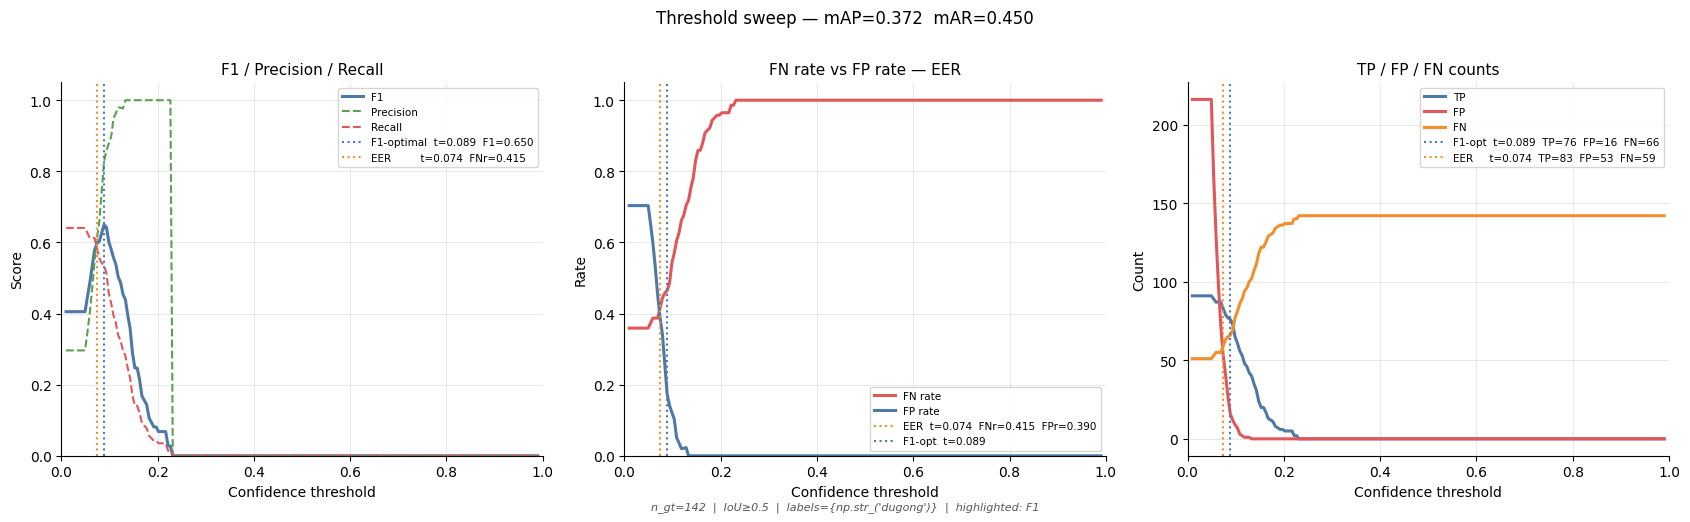

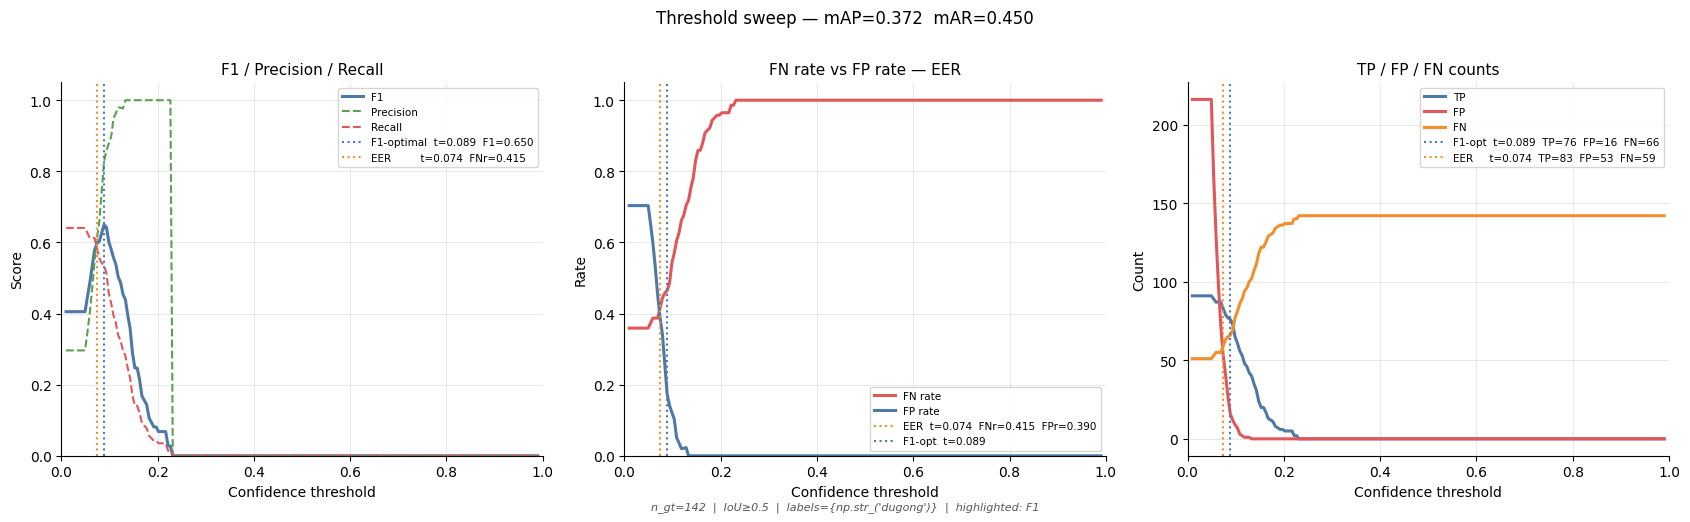

In [42]:
# plot the sweep
plot_sweep(results, method='f1')

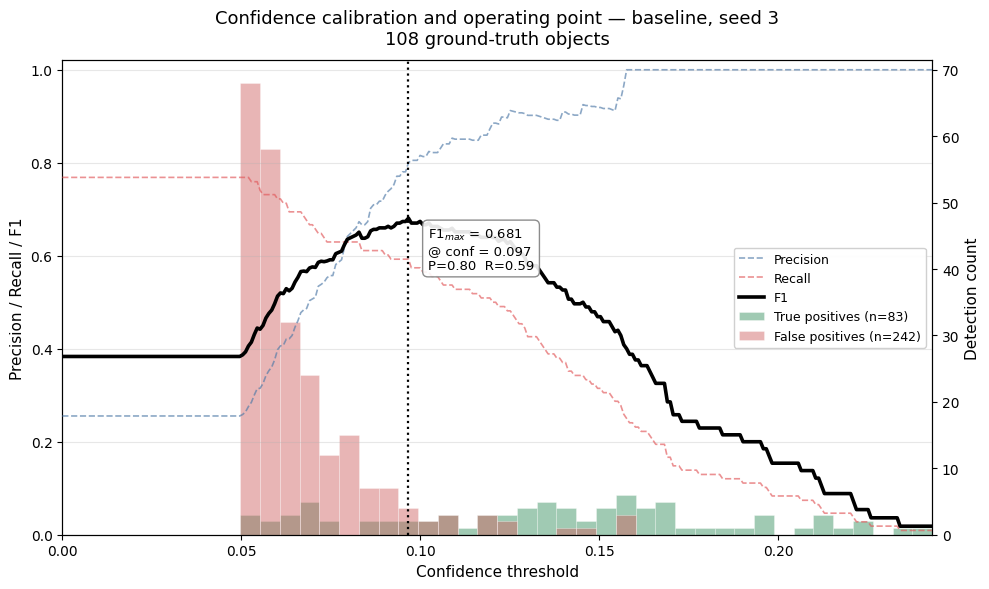

In [ ]:
import numpy as np, matplotlib.pyplot as plt

pred_field, eval_key, gt_field = "baseline_test3", "eval_test3", "ground_truth"

# ── pull detections + their tp/fp tags ───────────────────────────────────────
conf = np.array(view3.values(f"{pred_field}.detections.confidence", unwind=True), dtype=float)
tag  = np.array(view3.values(f"{pred_field}.detections.{eval_key}",  unwind=True))

tp_conf, fp_conf = conf[tag == "tp"], conf[tag == "fp"]
n_gt = view3.count(f"{gt_field}.detections")

# ── F1 as a function of threshold ────────────────────────────────────────────
ts = np.linspace(0, max(conf.max(), 0.05), 100)
tp_n = (tp_conf[:, None] >= ts).sum(0)          # TPs surviving each threshold
fp_n = (fp_conf[:, None] >= ts).sum(0)
prec = tp_n / np.maximum(tp_n + fp_n, 1e-9)
rec  = tp_n / max(n_gt, 1)
f1   = 2 * prec * rec / np.maximum(prec + rec, 1e-9)
best = int(np.argmax(f1))

# ── plot ─────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 6))
ax2 = ax.twinx()                                  # right axis: distributions

bins = np.linspace(0, ts.max(), 45)
ax2.hist(tp_conf, bins=bins, color="seagreen",  alpha=.45, edgecolor="white",
         linewidth=.5, label=f"True positives (n={len(tp_conf)})", zorder=1)
ax2.hist(fp_conf, bins=bins, color="indianred", alpha=.45, edgecolor="white",
         linewidth=.5, label=f"False positives (n={len(fp_conf)})", zorder=1)
ax2.set_ylabel("Detection count", fontsize=11)
ax2.grid(False)

# left axis: F1 (+ P and R faintly, for context)
ax.plot(ts, prec, color="#4e79a7", lw=1.2, ls="--", alpha=.65, label="Precision", zorder=3)
ax.plot(ts, rec,  color="#e15759", lw=1.2, ls="--", alpha=.65, label="Recall",    zorder=3)
ax.plot(ts, f1,   color="black",   lw=2.6, label="F1", zorder=4)

ax.axvline(ts[best], color="black", ls=":", lw=1.6, zorder=5)
ax.annotate(f"F1$_{{max}}$ = {f1[best]:.3f}\n@ conf = {ts[best]:.3f}\n"
            f"P={prec[best]:.2f}  R={rec[best]:.2f}",
            xy=(ts[best], f1[best]), xytext=(14, -6), textcoords="offset points",
            fontsize=9.5, va="top",
            bbox=dict(boxstyle="round,pad=0.4", fc="white", ec="grey", alpha=.9), zorder=6)

ax.set_zorder(ax2.get_zorder() + 1)   # curves in front of bars
ax.patch.set_visible(False)           # ...without hiding them

ax.set_xlabel("Confidence threshold", fontsize=11)
ax.set_ylabel("Precision / Recall / F1", fontsize=11)
ax.set_ylim(0, 1.02); ax.set_xlim(0, ts.max())
ax.grid(alpha=.3, axis="y")

h1, l1 = ax.get_legend_handles_labels()
h2, l2 = ax2.get_legend_handles_labels()
ax.legend(h1 + h2, l1 + l2, loc="center right", fontsize=9,
          framealpha=.92, ncol=1)

ax.set_title("Confidence calibration and operating point — baseline, seed 3\n"
             f"{n_gt} ground-truth objects", fontsize=13, pad=12)
fig.tight_layout()

    stage      thr       f1  n_tp  n_fp  median_tp
Zero-shot 0.096530 0.680851    83   242   0.137817
 Few-shot 0.093172 0.748815    99   131   0.120361


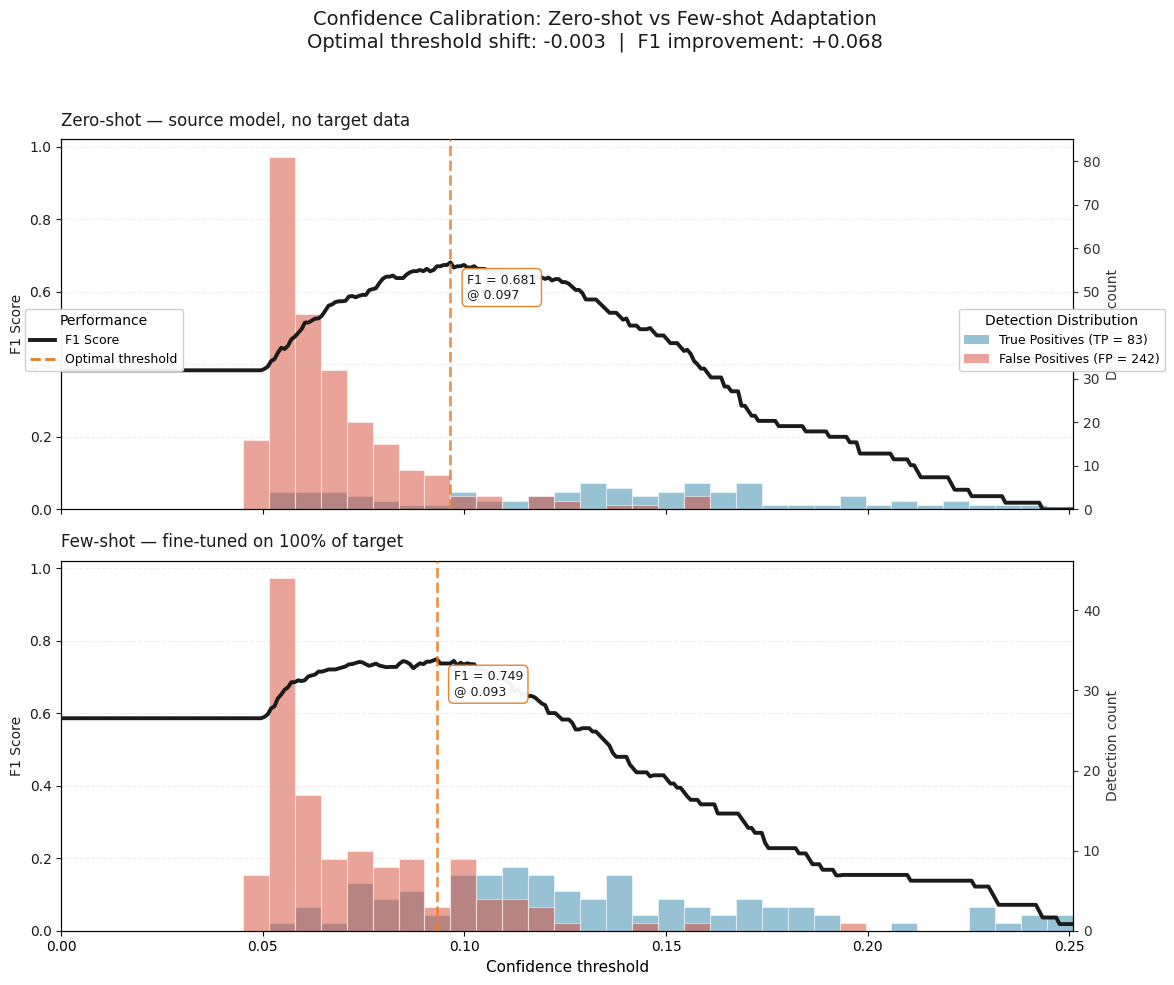

In [51]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

def confidence_panel(ax, view, pred_field, eval_key, gt_field, ts, title,
                     show_xlabel=True):
    """Draw a clean confidence calibration panel focusing on F1."""
    # Extract data
    conf = np.array(view.values(f"{pred_field}.detections.confidence", unwind=True), dtype=float)
    tag = np.array(view.values(f"{pred_field}.detections.{eval_key}", unwind=True))
    tp_conf, fp_conf = conf[tag == "tp"], conf[tag == "fp"]
    n_gt = view.count(f"{gt_field}.detections")

    # Calculate metrics
    tp_n = (tp_conf[:, None] >= ts).sum(0)
    fp_n = (fp_conf[:, None] >= ts).sum(0)
    prec = tp_n / np.maximum(tp_n + fp_n, 1e-9)
    rec = tp_n / max(n_gt, 1)
    f1 = 2 * prec * rec / np.maximum(prec + rec, 1e-9)
    best = int(np.argmax(f1))

    # Create twin axes for histograms
    ax2 = ax.twinx()
    
    # Histograms with clean colors
    bins = np.linspace(0, ts.max(), 40)
    ax2.hist(tp_conf, bins=bins, color="#2E86AB", alpha=0.5, edgecolor="white",
             lw=0.8, label=f"TP (n={len(tp_conf)})", zorder=1)
    ax2.hist(fp_conf, bins=bins, color="#D64933", alpha=0.5, edgecolor="white",
             lw=0.8, label=f"FP (n={len(fp_conf)})", zorder=1)
    ax2.set_ylabel("Detection count", fontsize=10, color="#333333")
    ax2.tick_params(axis='y', colors='#333333')
    ax2.grid(False)

    # Plot only F1 (clean and prominent)
    ax.plot(ts, f1, color="#1B1B1B", lw=2.8, label="F1", zorder=3)
    
    # Optimal threshold marker
    ax.axvline(ts[best], color="#E67E22", ls="--", lw=2, zorder=4, alpha=0.8)
    ax.annotate(f"F1 = {f1[best]:.3f}\n@ {ts[best]:.3f}",
                xy=(ts[best], f1[best]), xytext=(12, -8), textcoords="offset points",
                fontsize=9, va="top", color="#1B1B1B",
                bbox=dict(boxstyle="round,pad=0.4", fc="white", ec="#E67E22", alpha=0.95), zorder=5)

    # Axis styling
    ax.set_zorder(ax2.get_zorder() + 1)
    ax.patch.set_visible(False)
    ax.set_ylim(0, 1.02)
    ax.set_xlim(0, ts.max())
    ax.set_ylabel("F1 Score", fontsize=10, color="#1B1B1B")
    ax.tick_params(axis='y', colors='#1B1B1B')
    
    if show_xlabel:
        ax.set_xlabel("Confidence threshold", fontsize=11)
    
    ax.grid(alpha=0.2, axis="y", linestyle="--")
    ax.set_title(title, fontsize=12, loc="left", pad=10, color="#1B1B1B")

    # Return statistics
    return {
        'f1': f1[best], 'thr': ts[best],
        'n_tp': len(tp_conf), 'n_fp': len(fp_conf),
        'median_tp': float(np.median(tp_conf)) if len(tp_conf) else np.nan
    }


# ── Setup runs ──────────────────────────────────────────────────
runs = [
    (view3, "baseline_test3", "eval_test3", 
     "Zero-shot — source model, no target data"),
    (view3, "NNW_p100_random_seed3", "eval_p100_random_test3",
     "Few-shot — fine-tuned on 100% of target"),
]

# Shared threshold grid
cmax = max(
    np.array(v.values(f"{f}.detections.confidence", unwind=True), dtype=float).max()
    for v, f, _, _ in runs
)
ts = np.linspace(0, cmax, 300)

# ── Create figure with extra space for legends ──────────────────
fig, axes = plt.subplots(2, 1, figsize=(12, 10), sharex=True)
fig.subplots_adjust(right=0.78, hspace=0.25)

stats = []
for i, (v, pf, ek, title) in enumerate(runs):
    s = confidence_panel(axes[i], v, pf, ek, "ground_truth", ts, title,
                         show_xlabel=(i == len(runs) - 1))
    stats.append(s)

# ── Single legend on the right for TP/FP ──────────────────────
legend_elements = [
    Patch(facecolor="#2E86AB", alpha=0.5, label=f"True Positives (TP = {stats[0]['n_tp']:,})"),
    Patch(facecolor="#D64933", alpha=0.5, label=f"False Positives (FP = {stats[0]['n_fp']:,})"),
]
fig.legend(handles=legend_elements, 
           loc='center right', 
           bbox_to_anchor=(0.98, 0.65),
           title="Detection Distribution",
           title_fontsize=10,
           fontsize=9,
           framealpha=0.95,
           edgecolor='#CCCCCC')

# ── F1 legend on the left ──────────────────────────────────────
f1_line = plt.Line2D([0], [0], color="#1B1B1B", lw=2.8, label="F1 Score")
best_line = plt.Line2D([0], [0], color="#E67E22", ls="--", lw=2, label="Optimal threshold")
fig.legend(handles=[f1_line, best_line],
           loc='center left',
           bbox_to_anchor=(0.02, 0.65),
           title="Performance",
           title_fontsize=10,
           fontsize=9,
           framealpha=0.95,
           edgecolor='#CCCCCC')

# ── Title with stats ────────────────────────────────────────────
d_thr = stats[1]["thr"] - stats[0]["thr"]
d_f1 = stats[1]["f1"] - stats[0]["f1"]

fig.suptitle(
    f"Confidence Calibration: Zero-shot vs Few-shot Adaptation\n"
    f"Optimal threshold shift: {d_thr:+.3f}  |  F1 improvement: {d_f1:+.3f}",
    fontsize=14, y=0.98, color="#1B1B1B"
)

plt.tight_layout(rect=[0, 0, 0.95, 0.95])

# ── Print stats ─────────────────────────────────────────────────
import pandas as pd
df = pd.DataFrame(stats)
df['stage'] = ['Zero-shot', 'Few-shot']
print(df[['stage', 'thr', 'f1', 'n_tp', 'n_fp', 'median_tp']].to_string(index=False))

## Confidence Calibration Effects PLot

                                        stage      thr   thr_sd       f1    f1_sd        tp   fp  median_tp
                   Source Baseline on Target. 0.095238 0.004093 0.669204 0.018383 69.333333 15.0   0.135864
Fine-Tuned on partition 100 (entire training) 0.070175 0.011270 0.727848 0.012294 94.333333 42.0   0.110657


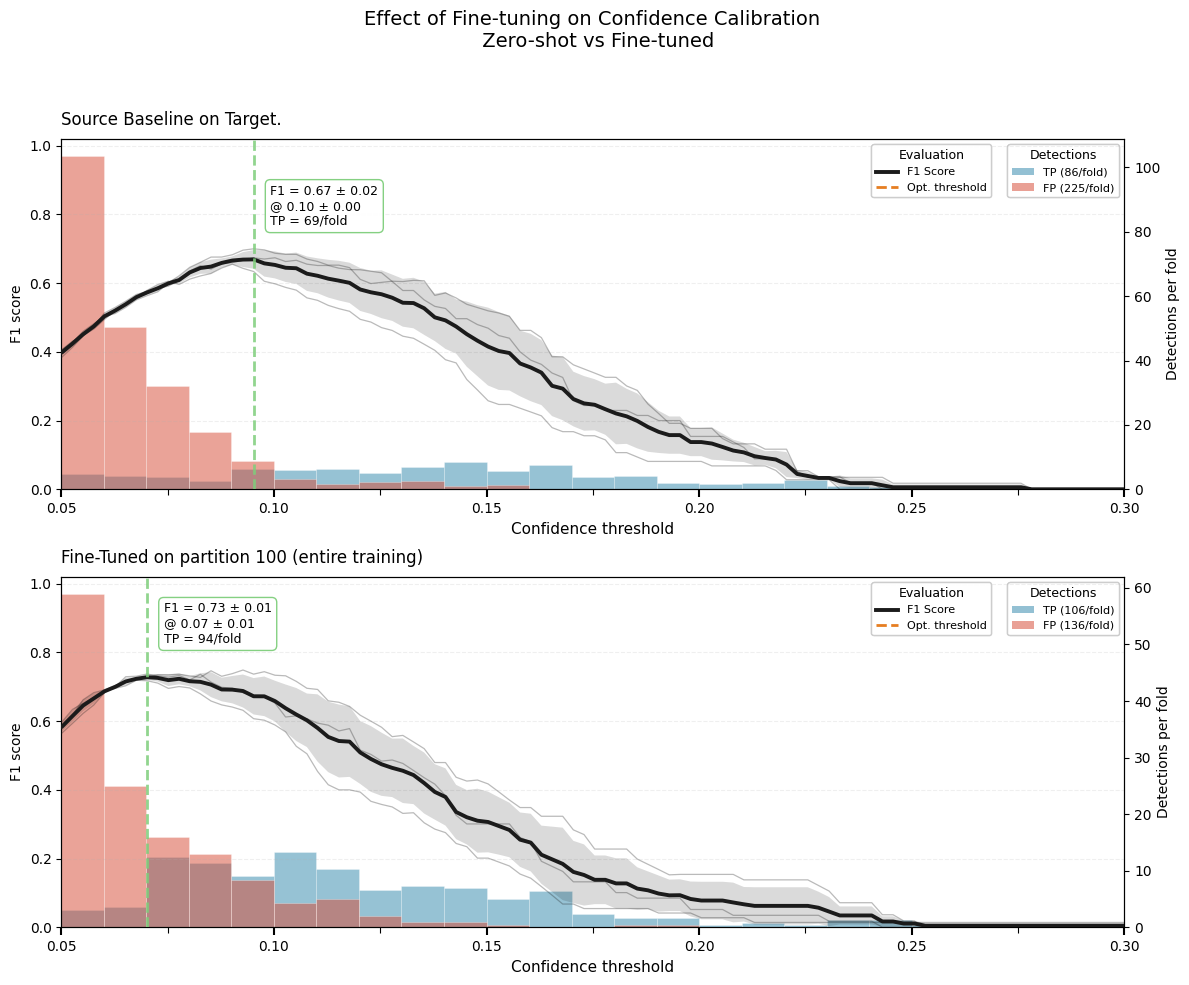

In [52]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from matplotlib.patches import Patch

def fold_curves(view, pred_field, eval_key, gt_field, ts):
    conf = np.array(view.values(f"{pred_field}.detections.confidence", unwind=True), dtype=float)
    tag  = np.array(view.values(f"{pred_field}.detections.{eval_key}",  unwind=True))
    tp_c, fp_c = conf[tag == "tp"], conf[tag == "fp"]
    n_gt = view.count(f"{gt_field}.detections")
    tp_n = (tp_c[:, None] >= ts).sum(0); fp_n = (fp_c[:, None] >= ts).sum(0)
    prec = tp_n / np.maximum(tp_n + fp_n, 1e-9)
    rec  = tp_n / max(n_gt, 1)
    f1   = 2 * prec * rec / np.maximum(prec + rec, 1e-9)
    b = int(np.argmax(f1))
    return dict(f1=f1, tp_c=tp_c, fp_c=fp_c, n_gt=n_gt,
                best_f1=f1[b], best_thr=ts[b],
                best_tp=int(tp_n[b]), best_fp=int(fp_n[b]),
                prec=prec[b], rec=rec[b])


def stage_panel(ax, folds, ts, title, show_legend=True,
                xlim=(0.01, 0.30)):
    """folds: list of dicts from fold_curves(), one per k-fold."""
    F = np.vstack([f["f1"] for f in folds])
    mu, sd = F.mean(0), F.std(0)
    b = int(np.argmax(mu))
    
    ax2 = ax.twinx()
    bins = np.arange(0, 1.01, 0.01)
    tp_all = np.concatenate([f["tp_c"] for f in folds])
    fp_all = np.concatenate([f["fp_c"] for f in folds])
    # weight so bars read as per-fold averages, not 3x inflated counts
    w = 1.0 / len(folds)
    ax2.hist(tp_all, bins=bins, weights=np.full(len(tp_all), w),
             color="#2E86AB", alpha=.5, edgecolor="white", lw=.4, zorder=1)
    ax2.hist(fp_all, bins=bins, weights=np.full(len(fp_all), w),
             color="#D64933", alpha=.5, edgecolor="white", lw=.4, zorder=1)
    ax2.set_ylabel("Detections per fold", fontsize=10)
    ax2.grid(False)

    # individual folds, faint
    for f in folds:
        ax.plot(ts, f["f1"], color="#1B1B1B", lw=.9, alpha=.30, zorder=3)
    ax.fill_between(ts, mu - sd, mu + sd, color="#1B1B1B", alpha=.16, lw=0, zorder=3)
    ax.plot(ts, mu, color="#1B1B1B", lw=2.8, zorder=4)

    ax.axvline(ts[b], color="#7ECE7B", ls="--", lw=2, alpha=.85, zorder=5)
    thr_sd = np.std([f["best_thr"] for f in folds])
    f1_sd  = np.std([f["best_f1"]  for f in folds])
    tp_mu  = np.mean([f["best_tp"] for f in folds])
    ax.annotate(f"F1 = {mu[b]:.2f} ± {f1_sd:.2f}\n@ {ts[b]:.2f} ± {thr_sd:.2f}\n"
                f"TP = {tp_mu:.0f}/fold",
                xy=(ts[b], mu[b]+0.25), xytext=(12, -8), 
                textcoords="offset points",
                fontsize=9, va="top",
                bbox=dict(boxstyle="round,pad=0.4", fc="white", ec="#7ECE7B", alpha=.95),
                zorder=6)

    ax.set_zorder(ax2.get_zorder() + 1); ax.patch.set_visible(False)
    ax.set_xlim(0.05,0.30); ax.set_ylim(0, 1.02)
    ax.xaxis.set_major_locator(ticker.MultipleLocator(0.05))
    ax.xaxis.set_minor_locator(ticker.MultipleLocator(0.025))
    
    # ── Tick styling ──────────────────────────────────────────────
    ax.tick_params(axis='x', which='major', length=6, width=1.5, labelsize=10)
    ax.tick_params(axis='x', which='minor', length=4, width=0.8)
    
    ax.set_ylabel("F1 score", fontsize=10)
    ax.set_xlabel("Confidence threshold", fontsize=11)  # Always show xlabel
    ax.grid(alpha=.2, axis="y", ls="--")
    ax.set_title(title, fontsize=12, loc="left", pad=10)

    # ── Always show legends for both plots ──────────────────────
    # Legend 1: Performance (F1, SD, optimal threshold)
    l1 = ax.legend(handles=[
        plt.Line2D([0],[0], color="#1B1B1B", lw=2.8, label=f"F1 Score"),
        #Patch(facecolor="#1B1B1B", alpha=.16, label="±1 Std"),
        plt.Line2D([0],[0], color="#E67E22", ls="--", lw=2, label="Opt. threshold")],
        loc="upper right", 
        bbox_to_anchor=(0.88, 1.0), fontsize=8, framealpha=.95, title="Evaluation", title_fontsize=9)
    ax.add_artist(l1)
    
    # Legend 2: Detections (TP/FP distribution)
    l2 = ax2.legend(handles=[
        Patch(facecolor="#2E86AB", alpha=.5, label=f"TP ({len(tp_all)/len(folds):.0f}/fold)"),
        Patch(facecolor="#D64933", alpha=.5, label=f"FP ({len(fp_all)/len(folds):.0f}/fold)")],
        loc="upper right", fontsize=8, framealpha=.95, title="Detections", title_fontsize=9)
    ax2.add_artist(l2)

    return dict(f1=mu[b], f1_sd=f1_sd, thr=ts[b], thr_sd=thr_sd,
                tp=tp_mu, fp=np.mean([f["best_fp"] for f in folds]),
                median_tp=float(np.median(tp_all)))


# ── configure your three folds ───────────────────────────────────────────────
ts = np.linspace(0, 1.0, 400)
VIEWS = {1: view1, 2: view2, 3: view3}

STAGES = [
    ("Source Baseline on Target.",
     {s: (f"baseline_test{s}",           f"eval_test{s}")            for s in VIEWS}),
    ("Fine-Tuned on partition 100 (entire training)",
     {s: (f"NNW_p100_random_seed{s}",    f"eval_p100_random_test{s}") for s in VIEWS}),
]

# ── Create figure WITHOUT sharex ─────────────────────────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(12, 10), sharex=False)
summary = []
for i, (title, spec) in enumerate(STAGES):
    folds = [fold_curves(VIEWS[s], pf, ek, "ground_truth", ts)
             for s, (pf, ek) in spec.items()]
    st = stage_panel(axes[i], folds, ts, title,
                     show_legend=True)  # Always show legends
    st["stage"] = title.split(" — ")[0]; summary.append(st)

d = summary[1]
z = summary[0]
fig.suptitle("Effect of Fine-tuning on Confidence Calibration \n Zero-shot vs Fine-tuned",
             fontsize=14, y=.98)
fig.tight_layout(rect=[0, 0, 1, .95]); fig.subplots_adjust(hspace=.25)

fig.savefig("/share/home/e2406743/code/Dugongs_IRISA-MARBEC-LIRMM/chapter3/models_run/ready_plots/confidence_calibration.pdf",
            format='pdf',
            bbox_inches='tight')

print(pd.DataFrame(summary)[["stage","thr","thr_sd","f1","f1_sd","tp","fp","median_tp"]]
      .to_string(index=False))

In [ ]:
df_seed = extract_all_metrics(
    results_dict = results,
    seed         = 2,
    method       = "f1",       # or "f1" — chosen after inspecting plot_sweep above
    # iou_thresh = None         # reads from res.config.iou automatically
)

In [ ]:
results3 = view3.evaluate_detections(
    "NNW_p100_random_seed3",
    gt_field="ground_truth",
    method="coco",
    eval_key="eval_p100_random_test3",
    iou=0.5,
    compute_mAP=True,
    
)

Text(0.5, 0, 'Budget (%)')

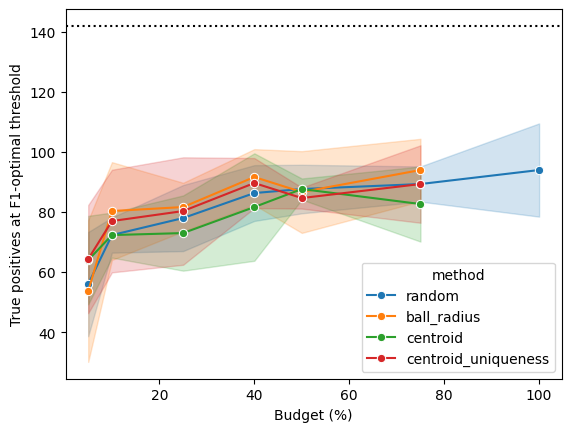

In [57]:
import seaborn as sns
d = df_join[(df_join.status=="ok") & (df_join.method!="baseline")]
sns.lineplot(data=d, x="partition_pct", y="tp", hue="method", marker="o", errorbar="sd")
plt.axhline(d.n_gt.iloc[0], ls=":", c="k")   # ceiling = total ground-truth objects
plt.ylabel("True positives at F1-optimal threshold"); plt.xlabel("Budget (%)")

# create the df with all inferences

In [4]:

from build_df_result_evaluation import build_results_dataframe

In [4]:
import sys

sys.path.append("/share/home/e2406743/code/Dugongs_IRISA-MARBEC-LIRMM/chapter2_FLPLAN/src")

from manage_fiftyone import (
    query_inference_jsons,
    remove_prediction_fields,
)

In [5]:
## get list of fields functions
def get_list_of_fields_for_seed(
    dataset,
    seed_term: str,
    verbose:   bool = True,
):
    """
    Return all prediction fields belonging to one seed, split into
    raw / nms / clean (excluding FiftyOne eval book-keeping fields).

    Parameters
    ----------
    dataset   : FiftyOne dataset or view
    seed_term : substring that identifies the seed, e.g. 'seed0', 'SEED63'
    verbose   : print counts

    Returns
    -------
    dict with keys: 'all', 'raw', 'nms', 'clean'
    """
    all_fields  = list(dataset.get_field_schema().keys())
    seed_fields = [f for f in all_fields if seed_term in f]

    raw   = [f for f in seed_fields if f.endswith("_raw")]
    nms   = [f for f in seed_fields if f.endswith("_nms")]
    clean = [
        f for f in seed_fields
        if not any(f.endswith(f"_{s}") for s in ("tp", "fp", "fn", "tn", "iou"))
    ]

    if verbose:
        print(f"seed_term='{seed_term}'  "
              f"total={len(seed_fields)}  "
              f"raw={len(raw)}  nms={len(nms)}  clean={len(clean)}")

    return {"all": seed_fields, "raw": raw, "nms": nms, "clean": clean}




def select_evaluation_list(
    all_op,
    baseline_field: str  = None,
    seed_term:      str  = None,
    deduplicate:    bool = True,
    verbose:        bool = True,
) :
    """
    Build the list of {pred_field, eval_key} dicts ready to pass to
    run_evaluations().

    Parameters
    ----------
    all_op          : list of prediction field names
    nms_or_raw      : 'nms' or 'raw'
    baseline_field  : optional explicit baseline field to append
    seed_term       : seed substring filter
    deduplicate     : remove duplicate pred_fields
    verbose         : print the final list
    """
    from collections import Counter
    def create_eval_key_name(f):
        return f.split('_',1)[1]
    
    eval_list = [
        {"pred_field": f, "eval_key": create_eval_key_name(f)}
        for f in all_op
    ]

    if baseline_field is not None:
        baseline_key = (
            f"baseline_{seed_term}"
            if seed_term else f"baseline_000"
        )
        eval_list.append({"pred_field": baseline_field, "eval_key": baseline_key})

    if deduplicate:
        counts = Counter(d["pred_field"] for d in eval_list)
        dups   = [k for k, v in counts.items() if v > 1]
        if dups and verbose:
            print(f"  WARNING: duplicate pred_fields: {dups}")

        seen: dict[str, dict] = {}
        for item in eval_list:
            key = item["pred_field"]
            if key not in seen:
                seen[key] = item
            elif "baseline" in item["eval_key"]:
                seen[key] = item
        eval_list = list(seen.values())

    if verbose:
        print(f"\nselect_evaluation_list → {len(eval_list)} entries "
              f"(seed='{seed_term}')")
        for e in eval_list:
            print(f"  {e['pred_field']:<55} → {e['eval_key']}")

    return eval_list


In [6]:
## add prediction function
from pathlib import Path
from fiftyone import ViewField as F
import json 

# ── box conversion (your version, + a degenerate-box guard) ───────────────────

def center_to_topleft(box):
    """
    Normalised RT-DETR centre [cx, cy, w, h] -> FiftyOne top-left [x, y, w, h].
    Returns None if the box collapses to zero area after clamping (so the caller
    can skip it -- FiftyOne rejects non-positive width/height).
    """
    cx, cy, w, h = box
    x = max(0.0, cx - w / 2)
    y = max(0.0, cy - h / 2)
    w = min(w, 1.0 - x)
    h = min(h, 1.0 - y)
    if w <= 0.0 or h <= 0.0:
        return None
    return [x, y, w, h]


# ── field name from filename ──────────────────────────────────────────────────

def derive_field_name(json_path, split_on="_rtdetr"):
    """
    Short field name from a prediction JSON filename: everything left of
    `split_on`. '.../NNW_p5_centroid_seed1_rtdetr_..._predictions.json'
    -> 'NNW_p5_centroid_seed1'. Falls back to the full stem if not present.
    """
    stem = Path(json_path).stem
    return stem.split(split_on)[0] if split_on in stem else stem


# ── load ONE json into ONE field ──────────────────────────────────────────────

def load_predictions_from_json(
    dataset,
    json_path,
    pred_field=None,
    split_on="_rtdetr",
    overwrite=True,
    verbose=True,
):
    """
    Load a single prediction JSON into `pred_field` (derived from the filename
    if None). Only samples whose filepath appears in the JSON are touched.

    Returns
    -------
    summary : dict {field, json_tiles, loaded, skipped, missing, detections}
        missing = JSON tiles with no matching sample in `dataset`
        skipped = matched samples left untouched because overwrite=False
    """
    json_path = Path(json_path)
    if pred_field is None:
        pred_field = derive_field_name(json_path, split_on)

    with open(json_path) as f:
        predictions = json.load(f)
    pred_lookup = {p["filepath"]: p for p in predictions}

    # restrict to the tiles this JSON actually predicts on -- fast + debuggable
    view = dataset.match(F("filepath").is_in(list(pred_lookup.keys())))
    n_matched = len(view)

    loaded = skipped = n_det = 0
    for sample in view.iter_samples(autosave=True, progress=verbose):
        if not overwrite and sample.get_field(pred_field) is not None:
            skipped += 1
            continue

        dets = []
        for det in pred_lookup[sample.filepath]["detections"]:
            box = center_to_topleft(det["bounding_box"])
            if box is None:
                continue
            dets.append(
                fo.Detection(
                    label=det["label"],
                    bounding_box=box,
                    confidence=det.get("confidence"),
                )
            )
        sample[pred_field] = fo.Detections(detections=dets)
        loaded += 1
        n_det += len(dets)

    missing = len(pred_lookup) - n_matched
    summary = {
        "field":       pred_field,
        "json_tiles":  len(pred_lookup),
        "loaded":      loaded,
        "skipped":     skipped,
        "missing":     missing,
        "detections":  n_det,
    }
    if verbose:
        flag = "  <-- MISSING TILES" if missing else ""
        print(f"  [{pred_field}] loaded={loaded} skipped={skipped} "
              f"missing={missing} dets={n_det}{flag}")
    return summary


# ── load MANY jsons: one field per file ───────────────────────────────────────

def add_prediction_fields(
    dataset,
    json_paths,
    split_on="_rtdetr",
    overwrite=True,
    verbose=True,
):
    """
    Add several prediction JSONs into the dataset, one field per file.

    Parameters
    ----------
    dataset     : FiftyOne dataset holding the tiles
    json_paths  : list of JSON paths (e.g. from query_inference_jsons)
    split_on    : token used to derive each field name from its filename
    overwrite   : overwrite an existing field of the same name
    verbose     : print a line per file

    Returns
    -------
    summaries : list of per-file dicts (see load_predictions_from_json), each
                also carrying 'json_path' and 'status'. Wrap in
                pd.DataFrame(summaries) for a one-glance overview.
    """
    summaries = []
    for i, jp in enumerate(json_paths):
        jp = Path(jp)
        if verbose:
            print(f"[{i+1}/{len(json_paths)}] {jp.name}")
        try:
            s = load_predictions_from_json(
                dataset, jp, pred_field=None,
                split_on=split_on, overwrite=overwrite, verbose=verbose,
            )
            s["json_path"] = str(jp)
            s["status"] = "ok"
        except Exception as exc:
            print(f"   ERROR: {exc}")
            s = {
                "field": derive_field_name(jp, split_on),
                "json_path": str(jp),
                "status": f"error: {exc}",
            }
        summaries.append(s)

    if verbose:
        ok = [s for s in summaries if s.get("status") == "ok"]
        print(f"\nAdded {len(ok)}/{len(summaries)} fields.")
        for s in summaries:
            if s.get("status") != "ok":
                print(f"  FAILED  {s['field']}: {s['status']}")
            elif s.get("missing"):
                print(f"  WARN    {s['field']}: {s['missing']} JSON tiles "
                      f"had no matching sample in the dataset")
    return summaries

In [7]:
## build results df 
from __future__ import annotations

import json
import re
import warnings
from pathlib import Path
import numpy as np
# ── metric helpers ────────────────────────────────────────────────────────────

def _ap_from_pr(recall, precision):
    """All-points AP (area under P-R curve). Single-class -> mAP@iou."""
    r = np.asarray(recall, dtype=float)
    p = np.asarray(precision, dtype=float)
    order = np.argsort(r)
    r, p = r[order], p[order]
    mrec = np.concatenate([[0.0], r, [1.0]])
    mpre = np.concatenate([[p[0] if len(p) else 0.0], p, [0.0]])
    for i in range(len(mpre) - 2, -1, -1):
        mpre[i] = max(mpre[i], mpre[i + 1])
    idx = np.where(mrec[1:] != mrec[:-1])[0]
    return float(np.sum((mrec[idx + 1] - mrec[idx]) * mpre[idx + 1]))


def _sweep_metrics(res, iou=0.5, n_thresholds=200):
    """
    Confidence sweep at a fixed IoU over a COCODetectionResults object.
    Returns the F1-optimal operating point plus AP@iou / max-recall@iou.
    Positive labels inferred from res.ytrue (handles 'dugong' + 'calf').
    """
    ytrue = np.array(res.ytrue)
    ypred = np.array(res.ypred)
    confs = np.array([v if v is not None else 0.0 for v in res.confs], dtype=float)
    ious  = np.array([v if v is not None else 0.0 for v in res.ious],  dtype=float)

    pos = set(np.unique(ytrue)) - {"(none)"}
    pos_arr = np.array(sorted(pos))            # np array, not list() -> immune to
    is_pos = lambda a: np.isin(a, pos_arr)     # a shadowed builtin `list` in the notebook

    n_gt = int((ypred == "(none)").sum() + (is_pos(ytrue) & is_pos(ypred)).sum())
    pred_mask = ypred != "(none)"

    ts = np.linspace(0.01, 0.99, n_thresholds)
    P = np.zeros(n_thresholds); R = np.zeros(n_thresholds); F = np.zeros(n_thresholds)
    TP = np.zeros(n_thresholds, int); FP = np.zeros(n_thresholds, int); FN = np.zeros(n_thresholds, int)

    for i, t in enumerate(ts):
        mask = pred_mask & (confs >= t)
        tp = int((is_pos(ytrue[mask]) & (ious[mask] >= iou)).sum())
        fp = int((ytrue[mask] == "(none)").sum())
        fn = n_gt - tp
        prec = tp / (tp + fp + 1e-9)
        rec  = tp / (tp + fn + 1e-9)
        P[i], R[i] = prec, rec
        F[i] = 2 * prec * rec / (prec + rec + 1e-9)
        TP[i], FP[i], FN[i] = tp, fp, fn

    b = int(np.argmax(F))
    return {
        "n_gt": n_gt,
        "positive_label": str(sorted(pos)),
        "mAP_50": _ap_from_pr(R, P),
        "mAR_50": float(R.max()),
        "f1_threshold": float(ts[b]),
        "f1": float(F[b]),
        "precision": float(P[b]),
        "recall": float(R[b]),
        "tp": int(TP[b]), "fp": int(FP[b]), "fn": int(FN[b]),
    }



_RUN_RE = re.compile(r"(?:^|_)p(\d+)_(.+?)_seed(\d+)(?:_|$)", re.IGNORECASE)

def parse_run_name_df(path, split_on="_rtdetr"):
    stem = Path(path).stem
    m = _RUN_RE.search(stem)
    if not m:
        return None
    pct = int(m.group(1))
    return {
        "method":        m.group(2).lower(),
        "partition":     pct / 100.0,      # ← the key that was missing
        "partition_pct": pct,
        "seed":          int(m.group(3)),
        "field_name":    stem.split(split_on)[0] if split_on in stem else stem,
    }

def build_results_dataframe(
    dataset,
    eval_list,                       # list of {"pred_field","eval_key"} from select_evaluation_list
    gt_field="ground_truth",
    view_tag_fmt="test_{seed}",
    eval_view=None,
    seed=None,                       # used for the view + as fallback seed for unparsable names
    iou=0.5,
    n_thresholds=200,
    classwise=False,
    store_eval_key=False,
    baseline_partition=1.0,          # partition assigned to the baseline row
    cache_path=None,
    verbose=True,
):
    """
    Evaluate prediction fields that ALREADY EXIST in the dataset (no
    reconstruction). One row per field, keyed by (method, partition, seed).

    eval_list : output of select_evaluation_list — dicts with 'pred_field'
                (the FiftyOne field to evaluate) and 'eval_key' (a label).
    seed      : integer seed for the eval view (view_tag_fmt.format(seed=seed))
                and the fallback seed column when a field name can't be parsed
                (e.g. 'baseline_test1'). Required unless eval_view is given.
    """
    def log(msg, level="info"):
        if verbose:
            pre = {"info": "  ", "ok": "OK  ", "warn": "WARN", "err": "ERR "}.get(level, "  ")
            print(f"[{pre}] {msg}")

    if eval_view is None and seed is None:
        raise ValueError("pass either eval_view, or seed (for view_tag_fmt).")

    view = eval_view if eval_view is not None else dataset.match_tags(view_tag_fmt.format(seed=seed))
    n_total = len(view)
    if n_total == 0:
        raise ValueError(f"eval view is empty (tag '{view_tag_fmt.format(seed=seed)}').")

    rows = []
    for i, item in enumerate(eval_list):
        field = item["pred_field"]
        label = item.get("eval_key", field)
        print(f"\n[{i+1}/{len(eval_list)}] {field}")

        ids = parse_run_name_df(field)              # parses 'NNW_p10_centroid_seed1' style names
        if ids is None:                          # baseline / unparsable -> explicit fallback
            ids = {"method": "baseline", "partition": baseline_partition,
                   "partition_pct": int(round(baseline_partition * 100)),
                   "seed": seed}
            log(f"'{field}' not parseable -> method='baseline', "
                f"partition={baseline_partition}, seed={seed}", "warn")

        try:
            # GT-presence check (ground_truth vs ground_truthv2 trap)
            n_gt_tiles = len(view.exists(gt_field))
            if n_gt_tiles < n_total:
                log(f"{n_total - n_gt_tiles}/{n_total} tiles lack '{gt_field}' "
                    f"-- their predictions count as FP.", "warn")

            res = view.evaluate_detections(
                field, gt_field=gt_field, method="coco", iou=iou,
                classwise=classwise, compute_mAP=True,
                eval_key=(label if store_eval_key else None),
            )
            m = _sweep_metrics(res, iou=iou, n_thresholds=n_thresholds)

            rows.append({
                "method": ids["method"],
                "partition": ids["partition"],
                "partition_pct": ids["partition_pct"],
                "seed": ids["seed"],
                "pred_field": field,
                "eval_key": label,
                "mAP_50": m["mAP_50"],
                "mAP_50_95": float(res.mAP()),
                "mAR": float(res.mAR()),
                "mAR_50": m["mAR_50"],
                "f1": m["f1"], "precision": m["precision"], "recall": m["recall"],
                "f1_threshold": m["f1_threshold"],
                "tp": m["tp"], "fp": m["fp"], "fn": m["fn"],
                "n_gt": m["n_gt"], "iou": iou,
                "positive_label": m["positive_label"], "status": "ok",
            })
            log(f"{ids['method']:<20} p{ids['partition_pct']:<3} seed{ids['seed']}  "
                f"mAP50={m['mAP_50']:.3f}  mAP50-95={res.mAP():.3f}  F1={m['f1']:.3f}", "ok")

        except Exception as exc:
            log(f"failed: {exc}", "err")
            rows.append({"method": ids.get("method"), "partition": ids.get("partition"),
                         "seed": ids.get("seed"), "pred_field": field, "eval_key": label,
                         "status": f"error: {exc}"})

    df = pd.DataFrame(rows)
    _report_completeness(df, verbose)
    if cache_path:
        _cache(df, cache_path, log)
    return df

# ── completeness + caching ────────────────────────────────────────────────────
def _report_completeness(df, verbose=True):
    if not verbose or df.empty:
        return
    ok = df[df["status"] == "ok"] if "status" in df else df
    bad = df[df["status"] != "ok"] if "status" in df else df.iloc[0:0]

    print("\n" + "=" * 60)
    print(f"  Ingest complete: {len(ok)} ok, {len(bad)} failed, {len(df)} total")
    print("=" * 60)

    if len(ok):
        # runs per (method, partition): should equal the number of seeds everywhere
        grid = ok.groupby(["method", "partition"]).size().unstack(fill_value=0)
        print("\n  runs per method x partition (each cell should = #seeds):")
        print(grid.to_string())

        dup = ok.groupby(["method", "partition", "seed"]).size()
        dup = dup[dup > 1]
        if len(dup):
            print("\n  WARNING duplicate (method,partition,seed) rows:")
            print(dup.to_string())

    if len(bad):
        print("\n  failed / skipped runs:")
        for _, r in bad.iterrows():
            print(f"    {r.get('pred_field','?'):<32} {r.get('status')}")

In [8]:
## inference dirs
inference_dir = "/share/home/e2406743/code/Dugongs_IRISA-MARBEC-LIRMM/chapter3/models_run/inference/400steps"
which_seed = 'seed2'


# ##
# view_test_0 = dataset.load_saved_view('view_test0')
# view_test_1= dataset.load_saved_view('view_test1')
# view_test_2 = dataset.load_saved_view('view_test2')


list_inferences = query_inference_jsons(
    inference_dir= inference_dir,
    seed=which_seed,
    pattern= "*_test_predictions.json",
)

  Found 75 JSON files in '400steps'
  Matched 25 / 75 files
    NNW_p100_random_seed2_rtdetr_0722_2331_test_predictions.json
    NNW_p10_ball_radius_seed2_rtdetr_0722_2250_test_predictions.json
    NNW_p10_centroid_seed2_rtdetr_0722_2238_test_predictions.json
    NNW_p10_centroid_uniqueness_seed2_rtdetr_0722_2246_test_predictions.json
    NNW_p10_random_seed2_rtdetr_0722_2250_test_predictions.json
    NNW_p25_ball_radius_seed2_rtdetr_0722_2301_test_predictions.json
    NNW_p25_centroid_seed2_rtdetr_0722_2259_test_predictions.json
    NNW_p25_centroid_uniqueness_seed2_rtdetr_0722_2259_test_predictions.json
    NNW_p25_random_seed2_rtdetr_0722_2304_test_predictions.json
    NNW_p40_ball_radius_seed2_rtdetr_0722_2310_test_predictions.json
    NNW_p40_centroid_seed2_rtdetr_0722_2305_test_predictions.json
    NNW_p40_centroid_uniqueness_seed2_rtdetr_0722_2309_test_predictions.json
    NNW_p40_random_seed2_rtdetr_0722_2311_test_predictions.json
    NNW_p50_ball_radius_seed2_rtdetr_0722_2317_

In [66]:
new_list_inferences=[]
for lis in list_inferences:
    ss = lis.stem.split('_')
    if "0722_2220" in ss:
        new_list_inferences.append(lis)

In [11]:

folder_s = "/share/home/e2406743/code/Dugongs_IRISA-MARBEC-LIRMM/chapter3/models_run/inference/400steps"
list_inferences_ = ['NNW_p100_random_seed1_rtdetr_0722_2220_test_predictions.json',
    'NNW_p100_random_seed2_rtdetr_0722_2331_test_predictions.json']

list_inferences = [os.path.join(folder_s,f) for f in list_inferences_] 

add_prediction_fields(
    dataset,
    list_inferences,
    split_on="_rtdetr",
    overwrite=True,
    verbose=True,
)

[1/2] NNW_p100_random_seed1_rtdetr_0722_2220_test_predictions.json
  72% |█████████████|-----| 69/96 [433.9ms elapsed, 169.8ms remaining, 159.0 samples/s] 

 100% |███████████████████| 96/96 [561.3ms elapsed, 0s remaining, 171.0 samples/s]      
  [NNW_p100_random_seed1] loaded=96 skipped=0 missing=0 dets=253
[2/2] NNW_p100_random_seed2_rtdetr_0722_2331_test_predictions.json
 100% |███████████████████| 88/88 [510.6ms elapsed, 0s remaining, 172.3 samples/s]      
  [NNW_p100_random_seed2] loaded=88 skipped=0 missing=0 dets=241

Added 2/2 fields.


[{'field': 'NNW_p100_random_seed1',
  'json_tiles': 96,
  'loaded': 96,
  'skipped': 0,
  'missing': 0,
  'detections': 253,
  'json_path': '/share/home/e2406743/code/Dugongs_IRISA-MARBEC-LIRMM/chapter3/models_run/inference/400steps/NNW_p100_random_seed1_rtdetr_0722_2220_test_predictions.json',
  'status': 'ok'},
 {'field': 'NNW_p100_random_seed2',
  'json_tiles': 88,
  'loaded': 88,
  'skipped': 0,
  'missing': 0,
  'detections': 241,
  'json_path': '/share/home/e2406743/code/Dugongs_IRISA-MARBEC-LIRMM/chapter3/models_run/inference/400steps/NNW_p100_random_seed2_rtdetr_0722_2331_test_predictions.json',
  'status': 'ok'}]

In [ ]:
add_prediction_fields(
    dataset,
    list_inferences,
    split_on="_rtdetr",
    overwrite=True,
    verbose=True,
)

In [9]:
from pathlib import Path
import os 
folder_s = "/share/home/e2406743/code/Dugongs_IRISA-MARBEC-LIRMM/chapter3/models_run/inference"
list_inferences_ = ['NNW_p100_random_seed1_rtdetr_0722_2220_test_predictions.json',
    'NNW_p100_random_seed2_rtdetr_0722_2331_test_predictions.json']

list_inferences = [os.path.join(folder_s,f) for f in list_inferences_] 
name_fiftyone_fields = ['p100_random_seed1_rtdetr','p100_random_seed2_detr',]
# add inside fiftyone
for new_infer, name_field in zip(list_inferences,name_fiftyone_fields):
    load_predictions_from_json(
                    dataset, 
                    new_infer, 
                    pred_field=name_field,
                    split_on="_rtdetr", 
                    overwrite=True, 
                    verbose=True,
                )

FileNotFoundError: [Errno 2] No such file or directory: '/share/home/e2406743/code/Dugongs_IRISA-MARBEC-LIRMM/chapter3/models_run/inference/NNW_p100_random_seed1_rtdetr_0722_2220_test_predictions.json'

In [ ]:
list_inferences

In [33]:
_RUN_RE = re.compile(r"(?:^|_)p(\d+)_(.+?)_seed(\d+)(?:_|$)", re.IGNORECASE)

def parse_run_name(path, split_on="_rtdetr"):
    stem = Path(path).stem
    m = _RUN_RE.search(stem)
    if not m:
        return None
    pct = int(m.group(1))
    return {
        "method":        m.group(2).lower(),
        "partition":     pct / 100.0,
        "partition_pct": pct,
        "seed":          int(m.group(3)),
        "field_name":    stem.split(split_on)[0] if split_on in stem else stem,
    }

parse_run_name("NNW_p10_centroid_seed2")

{'method': 'centroid',
 'partition': 0.1,
 'partition_pct': 10,
 'seed': 2,
 'field_name': 'NNW_p10_centroid_seed2'}

In [32]:
def parse_run_name(name):
    m = _RUN_RE.search(name)
    if not m:
        return None
    pct = int(m.group(1))
    return {"method": m.group(2).lower(), "partition_pct": pct, "seed": int(m.group(3))}
parse_run_name('NNW_p10_random_seed1_rtdetr_0722_2137')

{'method': 'random', 'partition_pct': 10, 'seed': 1}

In [33]:
## REMOVE FIELDS TO MAKE THE DATASET LIGHTHER
# reuse the same parser the ingest uses, so "is this a prediction field?" and
# "how is it keyed?" never drift apart
_RUN_RE = re.compile(r"(?:^|_)p(\d+)_(.+?)_seed(\d+)(?:_|$)", re.IGNORECASE)
 
 
def parse_run_name(name):
    m = _RUN_RE.search(name)
    if not m:
        return None
    pct = int(m.group(1))
    return {"method": m.group(2).lower(), "partition_pct": pct, "seed": int(m.group(3))}
 
 
def remove_prediction_fields(
    dataset,
    seed=None,               # "seed1" | ["seed1","seed2"] | 1 | [1,2]
    partition=None,          # "p10"   | ["p5","p10"]      | 10 | [5,10]
    method=None,             # "centroid" | ["centroid","random"]
    extra_terms=None,        # substrings that must ALL be present
    keep_baseline=True,
    include_eval=False,      # also remove FiftyOne eval bookkeeping (_tp/_fp/_fn/_tn/_iou)
    dry_run=True,
    verbose=True,
):
    """
    Remove prediction fields matching the filters. See module docstring.
 
    Filtering semantics
    -------------------
    - A field is a candidate only if parse_run_name() recognises it (or it is an
      eval-bookkeeping field, when include_eval=True).
    - seed / partition / method: within each filter, ANY value may match (OR);
      across filters, ALL supplied filters must match (AND).
    - Passing NO seed/partition/method filters selects EVERY prediction field
      (still respects keep_baseline and the protected set) -- use with care.
    - extra_terms: every listed substring must be present.
 
    Returns the list of field names deleted (or that would be, in dry_run).
    """
    def _to_list(v):
        if v is None:
            return None
        return [v] if isinstance(v, (str, int)) else list(v)
 
    seeds      = _to_list(seed)
    partitions = _to_list(partition)
    methods    = _to_list(method)
    extras     = _to_list(extra_terms)
 
    # normalise seed/partition tokens to the strings that appear in field names
    def _seed_tok(s):  return s if isinstance(s, str) else f"seed{s}"
    def _part_tok(p):  return p if isinstance(p, str) else f"p{p}"
    seeds      = [_seed_tok(s) for s in seeds] if seeds else None
    partitions = [_part_tok(p) for p in partitions] if partitions else None
 
    _EVAL_SUFFIXES = ("_tp", "_fp", "_fn", "_tn", "_iou")
 
    _PROTECTED = {
        "id", "filepath", "tags", "metadata", "created_at", "last_modified_at",
        "ground_truth", "ground_truthv2", "audit", "roi_grid",
        "region", "mission_name", "parent_name",
        "m_flight", "flight_mission", "name_plot",
        "full_embeddings", "full_emb_umap_dinov3", "v2_full_emb_umap_dinov3",
        "uniqueness_score", "representativeness_score",
        "cluster_label", "cluster_label_8",
        "uniqueness_score_per_cluster", "soft_coverage_score",
        "thumbnail_path",
    }
 
    all_fields = list(dataset.get_field_schema().keys())
 
    def _is_eval_field(name):
        return include_eval and any(name.endswith(s) for s in _EVAL_SUFFIXES)
 
    def _matches(name):
        if name in _PROTECTED:
            return False
 
        parsed = parse_run_name(name)
        # candidate = a recognised prediction field, or an eval bookkeeping field
        if parsed is None and not _is_eval_field(name):
            return False
 
        # for filtering, use the parsed run name if available, else the raw name
        # (eval fields like 'NNW_p10_centroid_seed1_tp' still contain the tokens)
        if seeds and not any(s in name for s in seeds):
            return False
        if partitions and not any(f"_{p}_" in f"_{name}_" for p in partitions):
            return False
        if methods and not any(m in name for m in methods):
            return False
        if extras and not all(e in name for e in extras):
            return False
        return True
 
    to_delete = sorted(f for f in all_fields if _matches(f))
 
    if keep_baseline:
        to_delete = [f for f in to_delete if "baseline" not in f.lower()]
 
    if not to_delete:
        print("  No matching prediction fields found.")
        return []
 
    tag = "DRY RUN --" if dry_run else "DELETING"
    print(f"\n  {tag} {len(to_delete)} fields:")
    for f in to_delete:
        p = parse_run_name(f)
        info = (f"  (method={p['method']} p{p['partition_pct']} seed{p['seed']})"
                if p else "  (eval bookkeeping)")
        print(f"    {f}{info}")
 
    if dry_run:
        print("\n  Dry run -- pass dry_run=False to commit deletion.")
        return to_delete
 
    n_ok = n_err = 0
    for f in to_delete:
        try:
            dataset.delete_sample_field(f)
            n_ok += 1
            if verbose:
                print(f"  deleted  {f}")
        except Exception as e:
            n_err += 1
            print(f"  ERROR deleting '{f}': {e}")
    dataset.save()
    print(f"\n  Done -- deleted {n_ok} fields ({n_err} errors)")
    return to_delete

In [59]:
list(dataset.get_field_schema().keys())

['id',
 'filepath',
 'tags',
 'metadata',
 'created_at',
 'last_modified_at',
 'type_label',
 'ground_truth',
 'region',
 'mission_name',
 'parent_name',
 'gt_field',
 'min_area_ratio',
 'n_boxes_in_tile',
 'n_boxes_written',
 'source_image',
 'tile_name',
 'x_start',
 'y_start',
 'dataset_sr',
 'train_cluster_label',
 'flight_unique',
 'subregion',
 'cluster_train_1',
 'cluster_train_2',
 'cluster_train_3',
 'baseline_test1',
 'eval_test1_tp',
 'eval_test1_fp',
 'eval_test1_fn',
 'baseline_test3',
 'baseline_test2',
 'eval_test2_tp',
 'eval_test2_fp',
 'eval_test2_fn',
 'eval_test3_tp',
 'eval_test3_fp',
 'eval_test3_fn',
 'NNW_p25_ball_radius_seed2',
 'NNW_p25_centroid_seed2',
 'NNW_p25_centroid_uniqueness_seed2',
 'NNW_p25_random_seed2']

In [30]:
_RUN_RE = re.compile(r"(?:^|_)p(\d+)_(.+?)_seed(\d+)(?:_|$)", re.IGNORECASE)
 
 
def parse_run_name(name):
    m = _RUN_RE.search(name)
    if not m:
        return None
    pct = int(m.group(1))
    return {"method": m.group(2).lower(), "partition_pct": pct, "seed": int(m.group(3))}
 
parse_run_name('NNW_p5_random_seed1_rtdetr_0722_2113')

{'method': 'random', 'partition_pct': 5, 'seed': 1}

In [60]:
manual_field_delete = ['NNW_p25_ball_radius_seed2',
 'NNW_p25_centroid_seed2',
 'NNW_p25_centroid_uniqueness_seed2',
 'NNW_p25_random_seed2']
dataset._delete_sample_fields(field_names=manual_field_delete,error_level=1)

In [58]:
#remove already analysed fields to make space in fiftyone mongo
remove_prediction_fields(
    dataset,
    seed="seed2",
    partition=["p5","p10","p40","p50","p75","p100"],
    method=["centroid","centroid_uniqueness","ball_radius","random"],
    dry_run=False
)


  DELETING 21 fields:
    NNW_p100_random_seed2  (method=random p100 seed2)
    NNW_p10_ball_radius_seed2  (method=ball_radius p10 seed2)
    NNW_p10_centroid_seed2  (method=centroid p10 seed2)
    NNW_p10_centroid_uniqueness_seed2  (method=centroid_uniqueness p10 seed2)
    NNW_p10_random_seed2  (method=random p10 seed2)
    NNW_p40_ball_radius_seed2  (method=ball_radius p40 seed2)
    NNW_p40_centroid_seed2  (method=centroid p40 seed2)
    NNW_p40_centroid_uniqueness_seed2  (method=centroid_uniqueness p40 seed2)
    NNW_p40_random_seed2  (method=random p40 seed2)
    NNW_p50_ball_radius_seed2  (method=ball_radius p50 seed2)
    NNW_p50_centroid_seed2  (method=centroid p50 seed2)
    NNW_p50_centroid_uniqueness_seed2  (method=centroid_uniqueness p50 seed2)
    NNW_p50_random_seed2  (method=random p50 seed2)
    NNW_p5_ball_radius_seed2  (method=ball_radius p5 seed2)
    NNW_p5_centroid_seed2  (method=centroid p5 seed2)
    NNW_p5_centroid_uniqueness_seed2  (method=centroid_uniqueness

  deleted  NNW_p100_random_seed2
  deleted  NNW_p10_ball_radius_seed2
  deleted  NNW_p10_centroid_seed2
  deleted  NNW_p10_centroid_uniqueness_seed2
  deleted  NNW_p10_random_seed2
  deleted  NNW_p40_ball_radius_seed2
  deleted  NNW_p40_centroid_seed2
  deleted  NNW_p40_centroid_uniqueness_seed2
  deleted  NNW_p40_random_seed2
  deleted  NNW_p50_ball_radius_seed2
  deleted  NNW_p50_centroid_seed2
  deleted  NNW_p50_centroid_uniqueness_seed2
  deleted  NNW_p50_random_seed2
  deleted  NNW_p5_ball_radius_seed2
  deleted  NNW_p5_centroid_seed2
  deleted  NNW_p5_centroid_uniqueness_seed2
  deleted  NNW_p5_random_seed2
  deleted  NNW_p75_ball_radius_seed2
  deleted  NNW_p75_centroid_seed2
  deleted  NNW_p75_centroid_uniqueness_seed2
  deleted  NNW_p75_random_seed2

  Done -- deleted 21 fields (0 errors)


['NNW_p100_random_seed2',
 'NNW_p10_ball_radius_seed2',
 'NNW_p10_centroid_seed2',
 'NNW_p10_centroid_uniqueness_seed2',
 'NNW_p10_random_seed2',
 'NNW_p40_ball_radius_seed2',
 'NNW_p40_centroid_seed2',
 'NNW_p40_centroid_uniqueness_seed2',
 'NNW_p40_random_seed2',
 'NNW_p50_ball_radius_seed2',
 'NNW_p50_centroid_seed2',
 'NNW_p50_centroid_uniqueness_seed2',
 'NNW_p50_random_seed2',
 'NNW_p5_ball_radius_seed2',
 'NNW_p5_centroid_seed2',
 'NNW_p5_centroid_uniqueness_seed2',
 'NNW_p5_random_seed2',
 'NNW_p75_ball_radius_seed2',
 'NNW_p75_centroid_seed2',
 'NNW_p75_centroid_uniqueness_seed2',
 'NNW_p75_random_seed2']

In [62]:
## add this list inside the dataset 
add_prediction_fields(
    dataset,
    list_inferences,
    split_on="_rtdetr",
    overwrite=True,
    verbose=True,
)

[1/25] NNW_p100_random_seed3_rtdetr_0723_0033_test_predictions.json
 100% |███████████████████| 90/90 [358.0ms elapsed, 0s remaining, 251.4 samples/s]      
  [NNW_p100_random_seed3] loaded=90 skipped=0 missing=0 dets=230
[2/25] NNW_p10_ball_radius_seed3_rtdetr_0722_2358_test_predictions.json
 100% |███████████████████| 90/90 [363.9ms elapsed, 0s remaining, 247.3 samples/s]      
  [NNW_p10_ball_radius_seed3] loaded=90 skipped=0 missing=0 dets=114
[3/25] NNW_p10_centroid_seed3_rtdetr_0722_2347_test_predictions.json
   0% ||------------------|  0/90 [9.4ms elapsed, ? remaining, ? samples/s] 

 100% |███████████████████| 90/90 [287.7ms elapsed, 0s remaining, 312.8 samples/s]      
  [NNW_p10_centroid_seed3] loaded=90 skipped=0 missing=0 dets=164
[4/25] NNW_p10_centroid_uniqueness_seed3_rtdetr_0722_2356_test_predictions.json
 100% |███████████████████| 90/90 [319.3ms elapsed, 0s remaining, 281.9 samples/s]      
  [NNW_p10_centroid_uniqueness_seed3] loaded=90 skipped=0 missing=0 dets=145
[5/25] NNW_p10_random_seed3_rtdetr_0722_2359_test_predictions.json
 100% |███████████████████| 90/90 [519.1ms elapsed, 0s remaining, 173.4 samples/s]      
  [NNW_p10_random_seed3] loaded=90 skipped=0 missing=0 dets=208
[6/25] NNW_p25_ball_radius_seed3_rtdetr_0723_0009_test_predictions.json
 100% |███████████████████| 90/90 [739.6ms elapsed, 0s remaining, 121.7 samples/s]      
  [NNW_p25_ball_radius_seed3] loaded=90 skipped=0 missing=0 dets=194
[7/25] NNW_p25_centroid_seed3_rtdetr_0723_0002_test_predictions.json
 100% |███████████████████| 90/90 [700.3ms elapsed, 0s remaining, 128.5 samples/

[{'field': 'NNW_p100_random_seed3',
  'json_tiles': 90,
  'loaded': 90,
  'skipped': 0,
  'missing': 0,
  'detections': 230,
  'json_path': '/share/home/e2406743/code/Dugongs_IRISA-MARBEC-LIRMM/chapter3/models_run/inference/400steps/NNW_p100_random_seed3_rtdetr_0723_0033_test_predictions.json',
  'status': 'ok'},
 {'field': 'NNW_p10_ball_radius_seed3',
  'json_tiles': 90,
  'loaded': 90,
  'skipped': 0,
  'missing': 0,
  'detections': 114,
  'json_path': '/share/home/e2406743/code/Dugongs_IRISA-MARBEC-LIRMM/chapter3/models_run/inference/400steps/NNW_p10_ball_radius_seed3_rtdetr_0722_2358_test_predictions.json',
  'status': 'ok'},
 {'field': 'NNW_p10_centroid_seed3',
  'json_tiles': 90,
  'loaded': 90,
  'skipped': 0,
  'missing': 0,
  'detections': 164,
  'json_path': '/share/home/e2406743/code/Dugongs_IRISA-MARBEC-LIRMM/chapter3/models_run/inference/400steps/NNW_p10_centroid_seed3_rtdetr_0722_2347_test_predictions.json',
  'status': 'ok'},
 {'field': 'NNW_p10_centroid_uniqueness_seed3

In [63]:
fields_seed = get_list_of_fields_for_seed(dataset, 
                                   seed_term=which_seed)
fields_seed.keys()

seed_term='seed3'  total=25  raw=0  nms=0  clean=25


dict_keys(['all', 'raw', 'nms', 'clean'])

In [64]:
dict_of_input = select_evaluation_list(
    fields_seed["all"],
    seed_term="seed3",
    baseline_field='baseline_test3'
)

dict_of_input


select_evaluation_list → 26 entries (seed='seed3')
  NNW_p100_random_seed3                                   → p100_random_seed3
  NNW_p10_ball_radius_seed3                               → p10_ball_radius_seed3
  NNW_p10_centroid_seed3                                  → p10_centroid_seed3
  NNW_p10_centroid_uniqueness_seed3                       → p10_centroid_uniqueness_seed3
  NNW_p10_random_seed3                                    → p10_random_seed3
  NNW_p25_ball_radius_seed3                               → p25_ball_radius_seed3
  NNW_p25_centroid_seed3                                  → p25_centroid_seed3
  NNW_p25_centroid_uniqueness_seed3                       → p25_centroid_uniqueness_seed3
  NNW_p25_random_seed3                                    → p25_random_seed3
  NNW_p40_ball_radius_seed3                               → p40_ball_radius_seed3
  NNW_p40_centroid_seed3                                  → p40_centroid_seed3
  NNW_p40_centroid_uniqueness_seed3                  

[{'pred_field': 'NNW_p100_random_seed3', 'eval_key': 'p100_random_seed3'},
 {'pred_field': 'NNW_p10_ball_radius_seed3',
  'eval_key': 'p10_ball_radius_seed3'},
 {'pred_field': 'NNW_p10_centroid_seed3', 'eval_key': 'p10_centroid_seed3'},
 {'pred_field': 'NNW_p10_centroid_uniqueness_seed3',
  'eval_key': 'p10_centroid_uniqueness_seed3'},
 {'pred_field': 'NNW_p10_random_seed3', 'eval_key': 'p10_random_seed3'},
 {'pred_field': 'NNW_p25_ball_radius_seed3',
  'eval_key': 'p25_ball_radius_seed3'},
 {'pred_field': 'NNW_p25_centroid_seed3', 'eval_key': 'p25_centroid_seed3'},
 {'pred_field': 'NNW_p25_centroid_uniqueness_seed3',
  'eval_key': 'p25_centroid_uniqueness_seed3'},
 {'pred_field': 'NNW_p25_random_seed3', 'eval_key': 'p25_random_seed3'},
 {'pred_field': 'NNW_p40_ball_radius_seed3',
  'eval_key': 'p40_ball_radius_seed3'},
 {'pred_field': 'NNW_p40_centroid_seed3', 'eval_key': 'p40_centroid_seed3'},
 {'pred_field': 'NNW_p40_centroid_uniqueness_seed3',
  'eval_key': 'p40_centroid_uniqueness

In [32]:
dict_input_man = [
    {"pred_field":"NNW_p100_random_seed2_rtdetr_0716_2317","eval_key":"p100_random15_seed2"},
    {"pred_field":"NNW_p100_random_seed2_rtdetr_0722_1248","eval_key":"p100_random45_seed2"},
    {"pred_field":"NNW_p100_random_seed2_rtdetr_0722_1615","eval_key":"p100_random5_seed2"}
]

In [19]:
list(dataset.get_field_schema().keys())

['id',
 'filepath',
 'tags',
 'metadata',
 'created_at',
 'last_modified_at',
 'type_label',
 'ground_truth',
 'region',
 'mission_name',
 'parent_name',
 'gt_field',
 'min_area_ratio',
 'n_boxes_in_tile',
 'n_boxes_written',
 'source_image',
 'tile_name',
 'x_start',
 'y_start',
 'dataset_sr',
 'train_cluster_label',
 'flight_unique',
 'subregion',
 'cluster_train_1',
 'cluster_train_2',
 'cluster_train_3',
 'baseline_test1',
 'eval_test1_tp',
 'eval_test1_fp',
 'eval_test1_fn',
 'baseline_test3',
 'baseline_test2',
 'eval_test2_tp',
 'eval_test2_fp',
 'eval_test2_fn',
 'eval_test3_tp',
 'eval_test3_fp',
 'eval_test3_fn',
 'NNW_p100_random_seed1_rtdetr_0722_2220',
 'NNW_p10_ball_radius_seed1_rtdetr_0722_2133',
 'NNW_p10_centroid_seed1_rtdetr_0722_2128',
 'NNW_p10_centroid_uniqueness_seed1_rtdetr_0722_2133',
 'NNW_p10_random_seed1_rtdetr_0722_2137',
 'NNW_p25_ball_radius_seed1_rtdetr_0722_2147',
 'NNW_p25_centroid_seed1_rtdetr_0722_2146',
 'NNW_p25_centroid_uniqueness_seed1_rtdetr_0722

In [12]:
view1 = dataset.match_tags('test_1')
view2 = dataset.match_tags('test_2')
view3 = dataset.match_tags('test_3')

#dataset.save_view("test1",view1)
#dataset.save_view("test2",view2)
#dataset.save_view("test3",view3)

In [45]:
dict_of_input
#dict_input_man

[{'pred_field': 'NNW_p100_random_seed2_rtdetr_0722_2331',
  'eval_key': 'p100_random_seed2_rtdetr_0722_2331'},
 {'pred_field': 'NNW_p10_ball_radius_seed2_rtdetr_0722_2250',
  'eval_key': 'p10_ball_radius_seed2_rtdetr_0722_2250'},
 {'pred_field': 'NNW_p10_centroid_seed2_rtdetr_0722_2238',
  'eval_key': 'p10_centroid_seed2_rtdetr_0722_2238'},
 {'pred_field': 'NNW_p10_centroid_uniqueness_seed2_rtdetr_0722_2246',
  'eval_key': 'p10_centroid_uniqueness_seed2_rtdetr_0722_2246'},
 {'pred_field': 'NNW_p10_random_seed2_rtdetr_0722_2250',
  'eval_key': 'p10_random_seed2_rtdetr_0722_2250'},
 {'pred_field': 'NNW_p25_ball_radius_seed2_rtdetr_0722_2301',
  'eval_key': 'p25_ball_radius_seed2_rtdetr_0722_2301'},
 {'pred_field': 'NNW_p25_centroid_seed2_rtdetr_0722_2259',
  'eval_key': 'p25_centroid_seed2_rtdetr_0722_2259'},
 {'pred_field': 'NNW_p25_centroid_uniqueness_seed2_rtdetr_0722_2259',
  'eval_key': 'p25_centroid_uniqueness_seed2_rtdetr_0722_2259'},
 {'pred_field': 'NNW_p25_random_seed2_rtdetr_0

In [13]:
dataset

Name:        wp_final_test
Media type:  image
Num samples: 476
Persistent:  True
Tags:        []
Sample fields:
    id:                                fiftyone.core.fields.ObjectIdField
    filepath:                          fiftyone.core.fields.StringField
    tags:                              fiftyone.core.fields.ListField(fiftyone.core.fields.StringField)
    metadata:                          fiftyone.core.fields.EmbeddedDocumentField(fiftyone.core.metadata.ImageMetadata)
    created_at:                        fiftyone.core.fields.DateTimeField
    last_modified_at:                  fiftyone.core.fields.DateTimeField
    type_label:                        fiftyone.core.fields.StringField
    ground_truth:                      fiftyone.core.fields.EmbeddedDocumentField(fiftyone.core.labels.Detections)
    region:                            fiftyone.core.fields.StringField
    mission_name:                      fiftyone.core.fields.StringField
    parent_name:                       

In [17]:
results3 = view1.evaluate_detections(
    "NNW_p100_random_seed1",
    gt_field="ground_truth",
    method="coco",
    eval_key="eval_p100_random_test1",
    iou=0.5,
    compute_mAP=True,
    
)

Evaluating detections...
 100% |███████████████████| 96/96 [436.0ms elapsed, 0s remaining, 220.2 samples/s]      
Performing IoU sweep...
 100% |███████████████████| 96/96 [542.9ms elapsed, 0s remaining, 176.8 samples/s]      


In [65]:
    import pandas as pd 
    df = build_results_dataframe(
        dataset,
        dict_of_input,                       # list of {"pred_field","eval_key"} from select_evaluation_list
        gt_field="ground_truth",
        eval_view=view3,
        seed=3,
        iou=0.5,
        n_thresholds=200,
        classwise=False,
        store_eval_key=False,
        baseline_partition=1.0,          # partition assigned to the baseline row
        cache_path=None,
        verbose=True
    )


[1/26] NNW_p100_random_seed3
Evaluating detections...
 100% |███████████████████| 90/90 [313.7ms elapsed, 0s remaining, 286.9 samples/s]      
Performing IoU sweep...
 100% |███████████████████| 90/90 [383.8ms elapsed, 0s remaining, 234.5 samples/s]      
[OK  ] random               p100 seed3  mAP50=0.779  mAP50-95=0.501  F1=0.743

[2/26] NNW_p10_ball_radius_seed3
Evaluating detections...
 100% |███████████████████| 90/90 [149.7ms elapsed, 0s remaining, 601.2 samples/s]     
Performing IoU sweep...
 100% |███████████████████| 90/90 [185.9ms elapsed, 0s remaining, 484.0 samples/s]     
[OK  ] ball_radius          p10  seed3  mAP50=0.537  mAP50-95=0.283  F1=0.658

[3/26] NNW_p10_centroid_seed3
Evaluating detections...
 100% |███████████████████| 90/90 [167.5ms elapsed, 0s remaining, 537.3 samples/s]     
Performing IoU sweep...
 100% |███████████████████| 90/90 [214.5ms elapsed, 0s remaining, 419.6 samples/s]     
[OK  ] centroid             p10  seed3  mAP50=0.562  mAP50-95=0.332  F1=

In [25]:
view3.first()

<SampleView: {
    'id': '6a33d1a619d8f6f6ef56931d',
    'media_type': 'image',
    'filepath': '/share/home/e2406743/dataset/tiles_all/umflplan/positive/images/FPLAN_M4_UM_M46_F1_2025_P_2-699847233596f_105__tile_2400_4000_t1024_o224.jpg',
    'tags': ['train_0', 'test_3', 'train_1', 'train_2'],
    'metadata': <ImageMetadata: {
        'size_bytes': 82733,
        'mime_type': 'image/jpeg',
        'width': 1024,
        'height': 1024,
        'num_channels': 3,
    }>,
    'created_at': datetime.datetime(2026, 7, 13, 17, 34, 8, 91000),
    'last_modified_at': datetime.datetime(2026, 7, 23, 21, 4, 38, 767000),
    'type_label': 'positive',
    'ground_truth': <Detections: {
        'detections': [
            <Detection: {
                'id': '6a33d1a219d8f6f6ef56928b',
                'attributes': {},
                'tags': [],
                'label': 'dugong',
                'bounding_box': [0.953125, 0.59277343755, 0.046875, 0.1376953125],
                'mask': None,
     

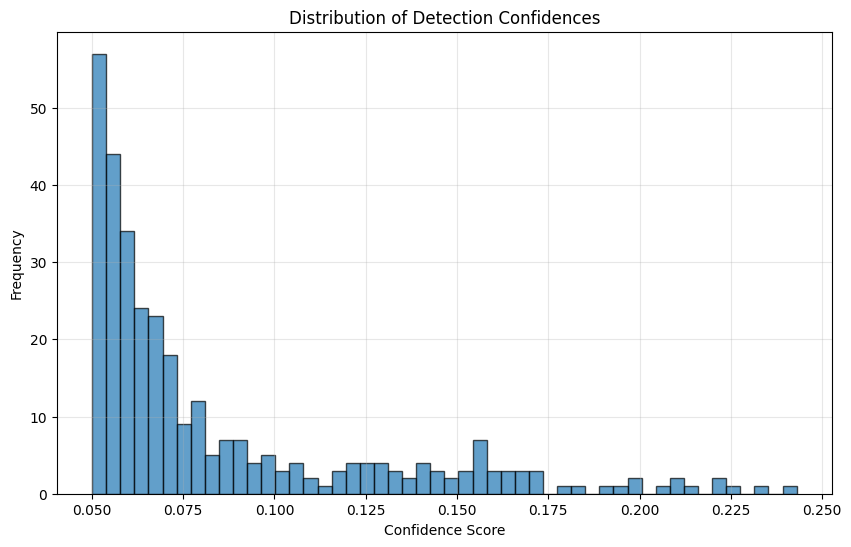

In [ ]:
# Get all confidence values flattened into a single list
confidences = view3.values('baseline_test3.detections.confidence')
flattened_confidences = [c for detections in confidences for c in detections]

# Plot histogram
plt.figure(figsize=(10, 6))
plt.hist(flattened_confidences, bins=50, edgecolor='black', alpha=0.7)
plt.xlabel('Confidence Score')
plt.ylabel('Frequency')
plt.title('Distribution of Detection Confidences for all predictions')
plt.grid(True, alpha=0.3)
plt.show()

325 detections | tags: {np.str_('fp'): np.int64(242), np.str_('tp'): np.int64(83)}


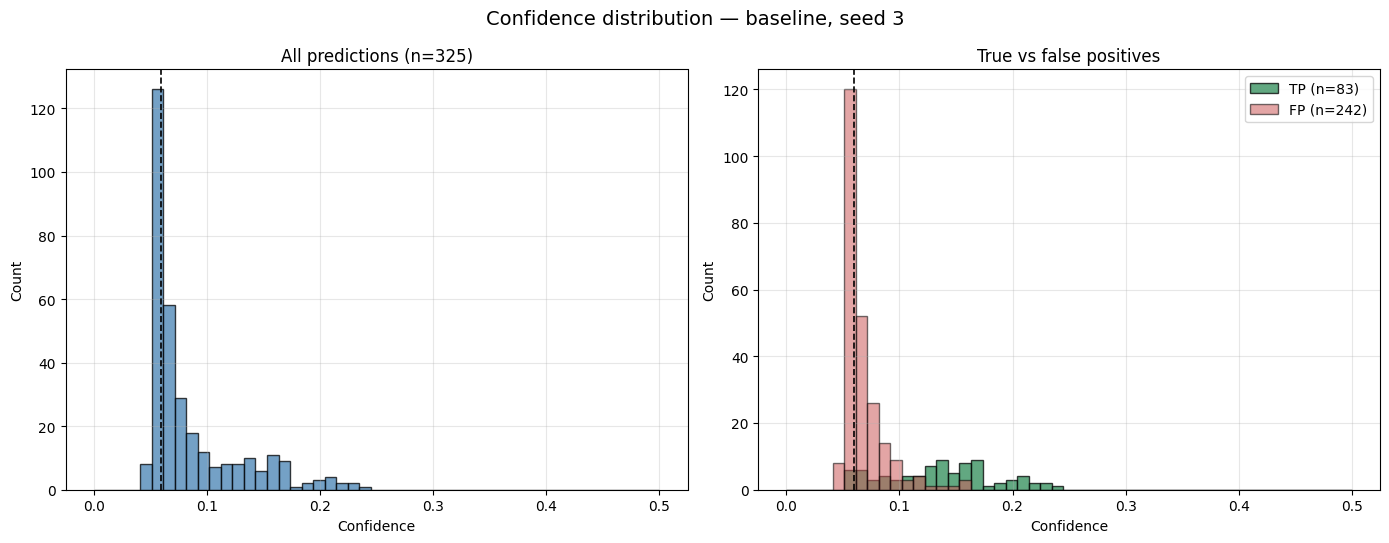

In [40]:
import numpy as np, matplotlib.pyplot as plt

pred_field, eval_key = "baseline_test3", "eval_test3"

conf = np.array(view3.values(f"{pred_field}.detections.confidence", unwind=True), dtype=float)
tag  = np.array(view3.values(f"{pred_field}.detections.{eval_key}",  unwind=True))

print(f"{len(conf)} detections | tags: {dict(zip(*np.unique(tag, return_counts=True)))}")

tp_conf = conf[tag == "tp"]
fp_conf = conf[tag == "fp"]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5.5), sharex=True)
bins = np.linspace(0, max(0.5, conf.max()), 50)

ax1.hist(conf, bins=bins, color="steelblue", edgecolor="black", alpha=.75)
ax1.set_title(f"All predictions (n={len(conf)})")

ax2.hist(tp_conf, bins=bins, color="seagreen", edgecolor="black", alpha=.75, label=f"TP (n={len(tp_conf)})")
ax2.hist(fp_conf, bins=bins, color="indianred", edgecolor="black", alpha=.55, label=f"FP (n={len(fp_conf)})")
ax2.legend(); ax2.set_title("True vs false positives")

for ax in (ax1, ax2):
    ax.set_xlabel("Confidence"); ax.set_ylabel("Count"); ax.grid(alpha=.3)
    ax.axvline(0.0595, ls="--", c="k", lw=1.2)      # your f1_threshold — swap in the real value

fig.suptitle("Confidence distribution — baseline, seed 3", fontsize=14)
fig.tight_layout()

In [ ]:
import numpy as np, matplotlib.pyplot as plt

pred_field, eval_key = "baseline_test3", "eval_test3"

conf = np.array(view3.values(f"{pred_field}.detections.confidence", unwind=True), dtype=float)
tag  = np.array(view3.values(f"{pred_field}.detections.{eval_key}",  unwind=True))

print(f"{len(conf)} detections | tags: {dict(zip(*np.unique(tag, return_counts=True)))}")

tp_conf = conf[tag == "tp"]
fp_conf = conf[tag == "fp"]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5.5), sharex=True)
bins = np.linspace(0, max(0.5, conf.max()), 50)

ax1.hist(conf, bins=bins, color="steelblue", edgecolor="black", alpha=.75)
ax1.set_title(f"All predictions (n={len(conf)})")

ax2.hist(tp_conf, bins=bins, color="seagreen", edgecolor="black", alpha=.75, label=f"TP (n={len(tp_conf)})")
ax2.hist(fp_conf, bins=bins, color="indianred", edgecolor="black", alpha=.55, label=f"FP (n={len(fp_conf)})")
ax2.legend(); ax2.set_title("True vs false positives")

for ax in (ax1, ax2):
    ax.set_xlabel("Confidence"); ax.set_ylabel("Count"); ax.grid(alpha=.3)
    ax.axvline(0.0595, ls="--", c="k", lw=1.2)      # your f1_threshold — swap in the real value

fig.suptitle("Confidence distribution — baseline, seed 3", fontsize=14)
fig.tight_layout()

In [41]:
dataset.list_evaluations()

['eval_test1', 'eval_test2', 'eval_test3']

In [ ]:
df.to_parquet("/share/home/e2406743/code/Dugongs_IRISA-MARBEC-LIRMM/chapter3/models_run/results_df/seed3_v2.parquet")

In [69]:
import re
from pathlib import Path

_RUN_RE = re.compile(r"(?:^|_)p(\d+)_(.+?)_seed(\d+)(?:_|$)", re.IGNORECASE)

def parse_run_name(path, split_on="_rtdetr"):
    stem = Path(path).stem
    m = _RUN_RE.search(stem)
    if not m:
        return None
    pct = int(m.group(1))
    return {
        "method":        m.group(2).lower(),
        "partition":     pct / 100.0,
        "partition_pct": pct,
        "seed":          int(m.group(3)),
        "field_name":    stem.split(split_on)[0] if split_on in stem else stem,
    }

print(parse_run_name("NNW_p100_random_seed1"))

{'method': 'random', 'partition': 1.0, 'partition_pct': 100, 'seed': 1, 'field_name': 'NNW_p100_random_seed1'}


In [32]:
all_fields = list(dataset.get_field_schema().keys())
all_fields

['id',
 'filepath',
 'tags',
 'metadata',
 'created_at',
 'last_modified_at',
 'type_label',
 'ground_truth',
 'region',
 'mission_name',
 'parent_name',
 'gt_field',
 'min_area_ratio',
 'n_boxes_in_tile',
 'n_boxes_written',
 'source_image',
 'tile_name',
 'x_start',
 'y_start',
 'dataset_sr',
 'train_cluster_label',
 'flight_unique',
 'subregion',
 'cluster_train_1',
 'cluster_train_2',
 'cluster_train_3',
 'baseline_test1',
 'eval_test1_tp',
 'eval_test1_fp',
 'eval_test1_fn',
 'baseline_test3',
 'baseline_test2',
 'eval_test2_tp',
 'eval_test2_fp',
 'eval_test2_fn',
 'eval_test3_tp',
 'eval_test3_fp',
 'eval_test3_fn',
 'NNW_p100_random_seed1',
 'NNW_p10_ball_radius_seed1',
 'NNW_p10_centroid_seed1',
 'NNW_p10_centroid_uniqueness_seed1',
 'NNW_p10_random_seed1',
 'NNW_p25_ball_radius_seed1',
 'NNW_p25_centroid_seed1',
 'NNW_p25_centroid_uniqueness_seed1',
 'NNW_p25_random_seed1',
 'NNW_p40_ball_radius_seed1',
 'NNW_p40_centroid_seed1',
 'NNW_p40_centroid_uniqueness_seed1',
 'NNW_p4

In [ ]:
session = fo.launch_app(view3,port=5151,auto=False)

In [108]:
view = dataset.match(
    F("eval_test1_fn") > 0
)
view

Dataset:     wp_final_test
Media type:  image
Num samples: 46
Sample fields:
    id:                                fiftyone.core.fields.ObjectIdField
    filepath:                          fiftyone.core.fields.StringField
    tags:                              fiftyone.core.fields.ListField(fiftyone.core.fields.StringField)
    metadata:                          fiftyone.core.fields.EmbeddedDocumentField(fiftyone.core.metadata.ImageMetadata)
    created_at:                        fiftyone.core.fields.DateTimeField
    last_modified_at:                  fiftyone.core.fields.DateTimeField
    type_label:                        fiftyone.core.fields.StringField
    ground_truth:                      fiftyone.core.fields.EmbeddedDocumentField(fiftyone.core.labels.Detections)
    region:                            fiftyone.core.fields.StringField
    mission_name:                      fiftyone.core.fields.StringField
    parent_name:                       fiftyone.core.fields.StringField
  

In [109]:
session.view = view

In [80]:
dataset.list_evaluations()

['eval_test1', 'eval_test2', 'eval_test3']

In [82]:
dataset

Name:        wp_final_test
Media type:  image
Num samples: 476
Persistent:  True
Tags:        []
Sample fields:
    id:                                fiftyone.core.fields.ObjectIdField
    filepath:                          fiftyone.core.fields.StringField
    tags:                              fiftyone.core.fields.ListField(fiftyone.core.fields.StringField)
    metadata:                          fiftyone.core.fields.EmbeddedDocumentField(fiftyone.core.metadata.ImageMetadata)
    created_at:                        fiftyone.core.fields.DateTimeField
    last_modified_at:                  fiftyone.core.fields.DateTimeField
    type_label:                        fiftyone.core.fields.StringField
    ground_truth:                      fiftyone.core.fields.EmbeddedDocumentField(fiftyone.core.labels.Detections)
    region:                            fiftyone.core.fields.StringField
    mission_name:                      fiftyone.core.fields.StringField
    parent_name:                       

In [86]:
view1.first()

<SampleView: {
    'id': '6a33d1a619d8f6f6ef56935a',
    'media_type': 'image',
    'filepath': '/share/home/e2406743/dataset/tiles_all/umflplan/positive/images/FPLAN_P4P_UM_M48_F1_2025_GSP-697e1055e6795_189__tile_0_2400_t1024_o224.jpg',
    'tags': ['train_0', 'test_1', 'train_2', 'train_3'],
    'metadata': <ImageMetadata: {
        'size_bytes': 66105,
        'mime_type': 'image/jpeg',
        'width': 1024,
        'height': 1024,
        'num_channels': 3,
    }>,
    'created_at': datetime.datetime(2026, 7, 13, 17, 34, 8, 91000),
    'last_modified_at': datetime.datetime(2026, 7, 21, 16, 42, 25, 725000),
    'type_label': 'positive',
    'ground_truth': <Detections: {
        'detections': [
            <Detection: {
                'id': '6a33d1a219d8f6f6ef5692cb',
                'attributes': {},
                'tags': [],
                'label': 'dugong',
                'bounding_box': [0.8193359375, 0.6728515625, 0.06640625, 0.05859375],
                'mask': None,
   

In [97]:

eval_patches = view1.to_evaluation_patches("eval_test1")
fp_patches = eval_patches.match(F("type") == "fn")

fp_patches
#session.view = fp_patches

Dataset:     wp_final_test
Media type:  image
Num patches: 51
Patch fields:
    id:               fiftyone.core.fields.ObjectIdField
    sample_id:        fiftyone.core.fields.ObjectIdField
    filepath:         fiftyone.core.fields.StringField
    tags:             fiftyone.core.fields.ListField(fiftyone.core.fields.StringField)
    metadata:         fiftyone.core.fields.EmbeddedDocumentField(fiftyone.core.metadata.ImageMetadata)
    created_at:       fiftyone.core.fields.DateTimeField
    last_modified_at: fiftyone.core.fields.DateTimeField
    ground_truth:     fiftyone.core.fields.EmbeddedDocumentField(fiftyone.core.labels.Detections)
    baseline_test1:   fiftyone.core.fields.EmbeddedDocumentField(fiftyone.core.labels.Detections)
    crowd:            fiftyone.core.fields.BooleanField
    type:             fiftyone.core.fields.StringField
    iou:              fiftyone.core.fields.FloatField
View stages:
    1. MatchTags(tags=['test_1'], bool=True, all=False)
    2. ToEvaluationPa

In [100]:
dataset

Name:        wp_final_test
Media type:  image
Num samples: 476
Persistent:  True
Tags:        []
Sample fields:
    id:                                fiftyone.core.fields.ObjectIdField
    filepath:                          fiftyone.core.fields.StringField
    tags:                              fiftyone.core.fields.ListField(fiftyone.core.fields.StringField)
    metadata:                          fiftyone.core.fields.EmbeddedDocumentField(fiftyone.core.metadata.ImageMetadata)
    created_at:                        fiftyone.core.fields.DateTimeField
    last_modified_at:                  fiftyone.core.fields.DateTimeField
    type_label:                        fiftyone.core.fields.StringField
    ground_truth:                      fiftyone.core.fields.EmbeddedDocumentField(fiftyone.core.labels.Detections)
    region:                            fiftyone.core.fields.StringField
    mission_name:                      fiftyone.core.fields.StringField
    parent_name:                       

## Join df and prepare plots

In [ ]:
import pandas as pd
df1 = pd.read_parquet("/share/home/e2406743/code/Dugongs_IRISA-MARBEC-LIRMM/chapter3/models_run/results_df/seed1_v2.parquet")
df2 = pd.read_parquet("/share/home/e2406743/code/Dugongs_IRISA-MARBEC-LIRMM/chapter3/models_run/results_df/seed2_v2.parquet")
df3 = pd.read_parquet("/share/home/e2406743/code/Dugongs_IRISA-MARBEC-LIRMM/chapter3/models_run/results_df/seed3_v2.parquet")


In [2]:
df_join = pd.concat([df1,df2,df3])

In [3]:
df_join.shape

(78, 21)

In [4]:
df_join.head()

,method,partition,partition_pct,seed,pred_field,eval_key,mAP_50,mAP_50_95,mAR,mAR_50,...,precision,recall,f1_threshold,tp,fp,fn,n_gt,iou,positive_label,status
0,random,1.0,100,1,NNW_p100_random_seed1_rtdetr_0722_2220,p100_random_seed1_rtdetr_0722_2220,0.675926,0.413768,0.588028,0.830986,...,0.677019,0.767606,0.069095,109,52,33,142,0.5,[np.str_('dugong')],ok
1,ball_radius,0.1,10,1,NNW_p10_ball_radius_seed1_rtdetr_0722_2133,p10_ball_radius_seed1_rtdetr_0722_2133,0.639794,0.348301,0.493662,0.739437,...,0.744361,0.697183,0.059246,99,34,43,142,0.5,[np.str_('dugong')],ok
2,centroid,0.1,10,1,NNW_p10_centroid_seed1_rtdetr_0722_2128,p10_centroid_seed1_rtdetr_0722_2128,0.553222,0.309881,0.435915,0.647887,...,0.800000,0.563380,0.064171,80,20,62,142,0.5,[np.str_('dugong')],ok
3,centroid_uniqueness,0.1,10,1,NNW_p10_centroid_uniqueness_seed1_rtdetr_0722_...,p10_centroid_uniqueness_seed1_rtdetr_0722_2133,0.594190,0.320781,0.488028,0.732394,...,0.659722,0.669014,0.059246,95,49,47,142,0.5,[np.str_('dugong')],ok
4,random,0.1,10,1,NNW_p10_random_seed1_rtdetr_0722_2137,p10_random_seed1_rtdetr_0722_2137,0.443793,0.259714,0.335211,0.492958,...,0.700000,0.492958,0.010000,70,30,72,142,0.5,[np.str_('dugong')],ok


In [10]:
df_join.columns

Index(['method', 'partition', 'partition_pct', 'seed', 'pred_field',
       'eval_key', 'mAP_50', 'mAP_50_95', 'mAR', 'mAR_50', 'f1', 'precision',
       'recall', 'f1_threshold', 'tp', 'fp', 'fn', 'n_gt', 'iou',
       'positive_label', 'status'],
      dtype='str')

In [6]:
df_join.loc[(df_join['partition_pct']==50)]

,method,partition,partition_pct,seed,pred_field,eval_key,mAP_50,mAP_50_95,mAR,mAR_50,...,precision,recall,f1_threshold,tp,fp,fn,n_gt,iou,positive_label,status
13,ball_radius,0.5,50,1,NNW_p50_ball_radius_seed1_rtdetr_0722_2209,p50_ball_radius_seed1_rtdetr_0722_2209,0.643863,0.362759,0.547887,0.816901,...,0.662338,0.718310,0.064171,102,52,40,142,0.5,[np.str_('dugong')],ok
14,centroid,0.5,50,1,NNW_p50_centroid_seed1_rtdetr_0722_2202,p50_centroid_seed1_rtdetr_0722_2202,0.632333,0.385120,0.559155,0.795775,...,0.716535,0.640845,0.069095,91,36,51,142,0.5,[np.str_('dugong')],ok
15,centroid_uniqueness,0.5,50,1,NNW_p50_centroid_uniqueness_seed1_rtdetr_0722_...,p50_centroid_uniqueness_seed1_rtdetr_0722_2203,0.636245,0.363784,0.551408,0.816901,...,0.758621,0.619718,0.078945,88,28,54,142,0.5,[np.str_('dugong')],ok
16,random,0.5,50,1,NNW_p50_random_seed1_rtdetr_0722_2209,p50_random_seed1_rtdetr_0722_2209,0.677992,0.410981,0.568310,0.809859,...,0.766129,0.669014,0.078945,95,29,47,142,0.5,[np.str_('dugong')],ok
13,ball_radius,0.5,50,2,NNW_p50_ball_radius_seed2,p50_ball_radius_seed2,0.680931,0.436328,0.602655,0.849558,...,0.656000,0.725664,0.069095,82,43,31,113,0.5,[np.str_('dugong')],ok
14,centroid,0.5,50,2,NNW_p50_centroid_seed2,p50_centroid_seed2,0.655659,0.358804,0.571681,0.858407,...,0.595745,0.743363,0.069095,84,57,29,113,0.5,[np.str_('dugong')],ok
15,centroid_uniqueness,0.5,50,2,NNW_p50_centroid_uniqueness_seed2,p50_centroid_uniqueness_seed2,0.641880,0.383961,0.597345,0.858407,...,0.637795,0.716814,0.069095,81,46,32,113,0.5,[np.str_('dugong')],ok
16,random,0.5,50,2,NNW_p50_random_seed2,p50_random_seed2,0.645914,0.386770,0.609735,0.867257,...,0.622378,0.787611,0.064171,89,54,24,113,0.5,[np.str_('dugong')],ok
13,ball_radius,0.5,50,3,NNW_p50_ball_radius_seed3,p50_ball_radius_seed3,0.793317,0.504276,0.712037,0.916667,...,0.817204,0.703704,0.093719,76,17,32,108,0.5,[np.str_('dugong')],ok
14,centroid,0.5,50,3,NNW_p50_centroid_seed3,p50_centroid_seed3,0.757255,0.494973,0.675000,0.898148,...,0.642336,0.814815,0.078945,88,49,20,108,0.5,[np.str_('dugong')],ok


# Plot

In [105]:
df_join.columns

Index(['method', 'partition', 'partition_pct', 'seed', 'pred_field',
       'eval_key', 'mAP_50', 'mAP_50_95', 'mAR', 'mAR_50', 'f1', 'precision',
       'recall', 'f1_threshold', 'tp', 'fp', 'fn', 'n_gt', 'iou',
       'positive_label', 'status'],
      dtype='str')

In [104]:
df_join.loc[df_join['method']=='baseline']

,method,partition,partition_pct,seed,pred_field,eval_key,mAP_50,mAP_50_95,mAR,mAR_50,...,precision,recall,f1_threshold,tp,fp,fn,n_gt,iou,positive_label,status
25,baseline,1.0,100,1,baseline_test1,baseline_seed1,0.569191,0.372370,0.450000,0.640845,...,0.826087,0.535211,0.088794,76,16,66,142,0.5,[np.str_('dugong')],ok
25,baseline,1.0,100,2,baseline_test2,baseline_seed2,0.634092,0.367137,0.497345,0.734513,...,0.797753,0.628319,0.093719,71,18,42,113,0.5,[np.str_('dugong')],ok
25,baseline,1.0,100,3,baseline_test3,baseline_seed3,0.633252,0.458222,0.579630,0.768519,...,0.805195,0.574074,0.098643,62,15,46,108,0.5,[np.str_('dugong')],ok


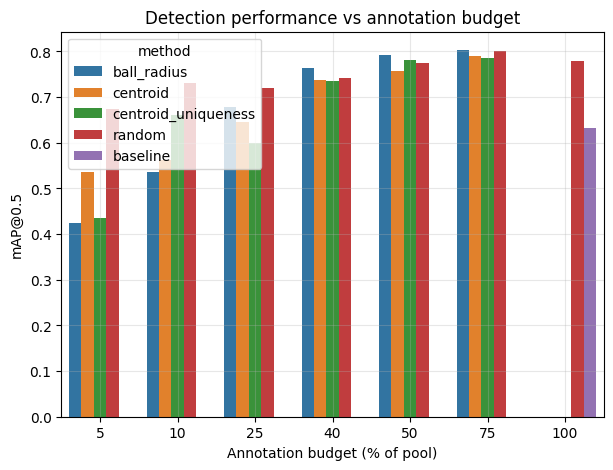

In [73]:
import seaborn as sns, matplotlib.pyplot as plt

d = df[df.status == "ok"]

fig, ax = plt.subplots(figsize=(7,5))
sns.barplot(data=d, x="partition_pct", y="mAP_50", hue="method", estimator=np.mean, capsize=.5, ax=ax)
ax.set_xlabel("Annotation budget (% of pool)")
ax.set_ylabel("mAP@0.5")
ax.set_title("Detection performance vs annotation budget")
ax.grid(alpha=.3)

In [45]:
df_long

,method,partition,metric,value
0,random,1.0,mAP_50,0.579942
1,random,1.0,mAP_50,0.381600
2,random,1.0,mAP_50,0.737799
3,random,1.0,mAP_50_95,0.358341
4,random,1.0,mAP_50_95,0.253743
5,random,1.0,mAP_50_95,0.475642
6,random,1.0,mAR,0.459292
7,random,1.0,mAR,0.284956
8,random,1.0,mAR,0.634513
9,random,1.0,mAR_50,0.681416


In [ ]:
pd.get_option()

<function pandas.get_option(pat: 'str') -> 'Any'>

In [90]:
with pd.option_context(
    "display.max_rows", None,
    "display.max_columns", None,
):
    print(df_join.loc[df_join['seed']==3])

                 method  partition  partition_pct  seed  \
0                random       1.00            100     3   
1           ball_radius       0.10             10     3   
2              centroid       0.10             10     3   
3   centroid_uniqueness       0.10             10     3   
4                random       0.10             10     3   
5           ball_radius       0.25             25     3   
6              centroid       0.25             25     3   
7   centroid_uniqueness       0.25             25     3   
8                random       0.25             25     3   
9           ball_radius       0.40             40     3   
10             centroid       0.40             40     3   
11  centroid_uniqueness       0.40             40     3   
12               random       0.40             40     3   
13          ball_radius       0.50             50     3   
14             centroid       0.50             50     3   
15  centroid_uniqueness       0.50             50     3 

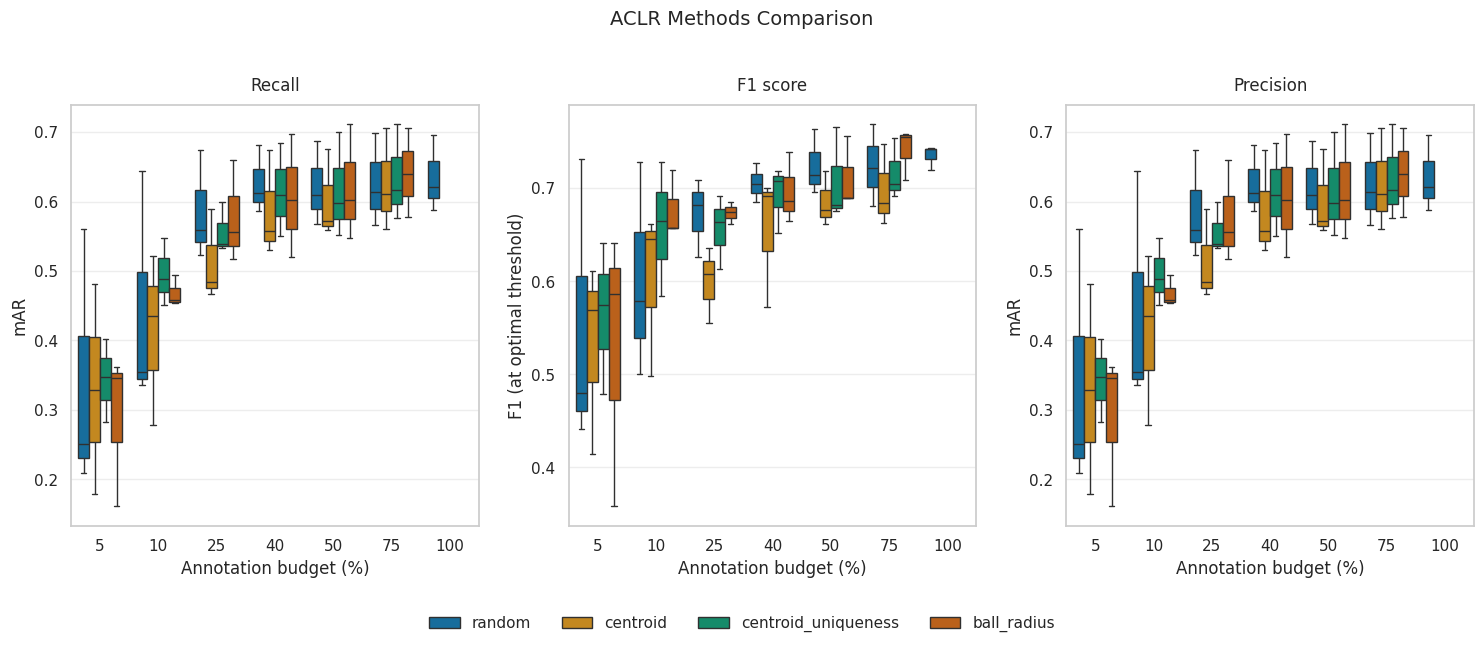

In [93]:

dat = df_join.loc[df_join["method"] != "baseline"].copy()

# fixed method order + palette so colours are consistent across every figure
order = ["random", "centroid", "centroid_uniqueness", "ball_radius"]
palette = dict(zip(order, sns.color_palette("colorblind", len(order))))
dat["method"] = pd.Categorical(dat["method"], categories=order, ordered=True)

sns.set_theme(style="whitegrid", context="notebook")

fig, axes = plt.subplots(1, 3, figsize=(15, 6), sharex=True)

specs = [("mAR", "mAR", "Recall"),
         ("f1",  "F1 (at optimal threshold)", "F1 score"),
         ("mAR", "mAR","Precision")]

for ax, (col, ylab, title) in zip(axes, specs):
    sns.boxplot(data=dat, x="partition_pct", y=col, hue="method",
                order=sorted(dat["partition_pct"].unique()),
                hue_order=order, palette=palette,
                width=.75, fliersize=2.5, linewidth=1.0, ax=ax)

    ax.set_title(title, fontsize=12, pad=10)
    ax.set_xlabel("Annotation budget (%)")
    ax.set_ylabel(ylab)
    ax.grid(axis="y", alpha=.35)
    ax.grid(axis="x", visible=False)
    ax.legend_.remove()                      # drop per-axes legends

# one shared legend under both panels
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, #title="Selection method",
           loc="lower center", bbox_to_anchor=(0.5, -0.04),
           ncol=len(order), frameon=False)

fig.suptitle("ACLR Methods Comparison", fontsize=14, y=1.02)
fig.tight_layout()
fig.subplots_adjust(wspace=0.22, bottom=0.16)
# fig.savefig("al_mar_f1.png", dpi=300, bbox_inches="tight")

In [97]:
df_join.columns

Index(['method', 'partition', 'partition_pct', 'seed', 'pred_field',
       'eval_key', 'mAP_50', 'mAP_50_95', 'mAR', 'mAR_50', 'f1', 'precision',
       'recall', 'f1_threshold', 'tp', 'fp', 'fn', 'n_gt', 'iou',
       'positive_label', 'status'],
      dtype='str')

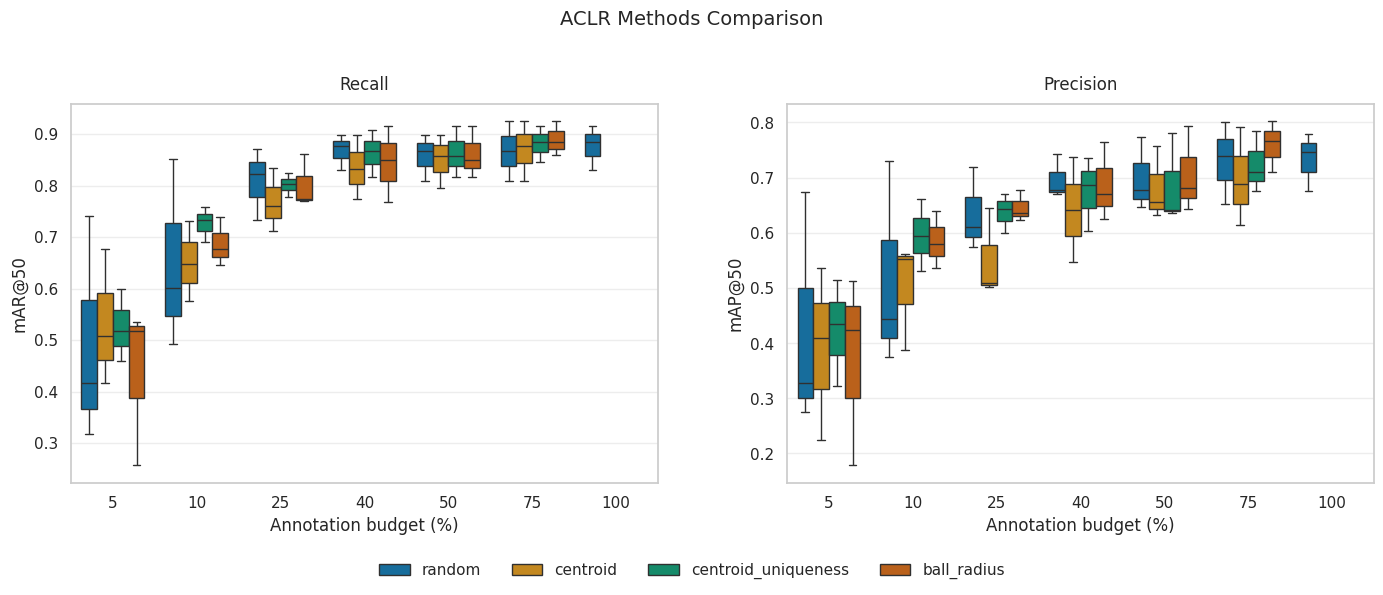

In [75]:

dat = df_join.loc[df_join["method"] != "baseline"].copy()

# fixed method order + palette so colours are consistent across every figure
order = ["random", "centroid", "centroid_uniqueness", "ball_radius"]
palette = dict(zip(order, sns.color_palette("colorblind", len(order))))
dat["method"] = pd.Categorical(dat["method"], categories=order, ordered=True)

sns.set_theme(style="whitegrid", 
              context="notebook")

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5), sharex=True)
ax
specs = [("mAR_50", "mAR@50", "Recall"),
         ("mAP_50", "mAP@50","Precision")]

for ax, (col, ylab, title) in zip(axes.flatten(), specs):
    sns.boxplot(data=dat, x="partition_pct", y=col, hue="method",
                order=sorted(dat["partition_pct"].unique()),
                hue_order=order, palette=palette,
                width=.75, fliersize=2.5, linewidth=1.0, ax=ax)

    ax.set_title(title, fontsize=12, pad=10)
    ax.set_xlabel("Annotation budget (%)")
    ax.set_ylabel(ylab)
    ax.grid(axis="y", alpha=.35)
    ax.grid(axis="x", visible=False)
    ax.legend_.remove()                      # drop per-axes legends

# one shared legend under both panels
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, #title="Selection method",
           loc="lower center", bbox_to_anchor=(0.5, -0.04),
           ncol=len(order), frameon=False)

fig.suptitle("ACLR Methods Comparison", fontsize=14, y=1.02)
fig.tight_layout()
fig.subplots_adjust(wspace=0.22, bottom=0.16)
# fig.savefig("al_mar_f1.png", dpi=300, bbox_inches="tight")

In [4]:
baseline_df = df_join.loc[df_join["method"] == "baseline"].copy()
baseline_df.groupby('method')[['mAP_50','mAP_50_95','mAR_50','f1']].agg(['mean','std'])

mAP_50           mAP_50_95              mAR_50            \
              mean       std      mean       std      mean       std   
method                                                                 
baseline  0.612178  0.037231  0.399243  0.051144  0.714626  0.066119   

                f1            
              mean       std  
method                        
baseline  0.674271  0.026923

In [9]:
baseline_df.select_dtypes(include='float')

,partition,mAP_50,mAP_50_95,mAR,mAR_50,f1,precision,recall,f1_threshold,iou
25,1.0,0.569191,0.372370,0.450000,0.640845,0.649573,0.826087,0.535211,0.088794,0.5
25,1.0,0.634092,0.367137,0.497345,0.734513,0.702970,0.797753,0.628319,0.093719,0.5
25,1.0,0.633252,0.458222,0.579630,0.768519,0.670270,0.805195,0.574074,0.098643,0.5


In [4]:
partitions = df_join.loc[df_join["method"] != "baseline"].copy()
partitions.groupby(['method','partition_pct'])[['mAP_50','mAR_50','precision','recall','f1']].agg(['mean','std']).round(2)

mAP_50       mAR_50       precision        \
                                    mean   std   mean   std      mean   std   
method              partition_pct                                             
ball_radius         5               0.37  0.17   0.44  0.16      0.69  0.10   
                    10              0.59  0.05   0.69  0.05      0.70  0.05   
                    25              0.65  0.03   0.80  0.05      0.68  0.07   
                    40              0.69  0.07   0.84  0.07      0.64  0.03   
                    50              0.71  0.08   0.86  0.05      0.71  0.09   
                    75              0.76  0.05   0.89  0.03      0.71  0.03   
centroid            5               0.39  0.16   0.53  0.13      0.54  0.12   
                    10              0.50  0.10   0.65  0.08      0.62  0.18   
                    25              0.55  0.08   0.77  0.06      0.61  0.11   
                    40              0.64  0.10   0.83  0.06      0.65  0.08   
                    50              0.68  0.07   0.85  0.05      0.65  0.06   
                    75              0.70  0.09   0.87  0.06      0.72  0.09   
centroid_uniqueness 5               0.42  0.10   0.53  0.07      0.61  0.10   
                    10              0.60  0.06   0.73  0.03      0.69  0.07   
                    25              0.64  0.04   0.80  0.02      0.65  0.03   
                    40              0.68  0.07   0.86  0.05      0.65  0.03   
                    50              0.69  0.08   0.86  0.05      0.71  0.07   
                    75              0.72  0.06   0.88  0.04      0.71  0.11   
random              5               0.43  0.22   0.49  0.22      0.68  0.10   
                    10              0.52  0.19   0.65  0.18      0.62  0.16   
                    25              0.63  0.08   0.81  0.07      0.72  0.13   
                    40              0.70  0.04   0.87  0.03      0.70  0.08   
                    50              0.70  0.07   0.86  0.04      0.73  0.09   
                    75              0.73  0.07   0.87  0.06      0.71  0.04   
                    100             0.73  0.05   0.88  0.04      0.70  0.05   

                                  recall          f1        
                                    mean   std  mean   std  
method              partition_pct                           
ball_radius         5               0.44  0.16  0.53  0.15  
                    10              0.66  0.05  0.68  0.04  
                    25              0.68  0.05  0.67  0.01  
                    40              0.76  0.06  0.70  0.04  
                    50              0.72  0.01  0.71  0.04  
                    75              0.78  0.03  0.74  0.03  
centroid            5               0.53  0.13  0.53  0.10  
                    10              0.60  0.06  0.60  0.09  
                    25              0.60  0.04  0.60  0.04  
                    40              0.68  0.16  0.65  0.07  
                    50              0.73  0.09  0.69  0.03  
                    75              0.68  0.00  0.70  0.04  
centroid_uniqueness 5               0.53  0.07  0.57  0.08  
                    10              0.63  0.08  0.66  0.07  
                    25              0.66  0.05  0.66  0.04  
                    40              0.75  0.04  0.69  0.04  
                    50              0.71  0.08  0.71  0.05  
                    75              0.74  0.07  0.72  0.03  
random              5               0.48  0.20  0.55  0.16  
                    10              0.61  0.12  0.60  0.12  
                    25              0.65  0.04  0.67  0.04  
                    40              0.72  0.06  0.71  0.02  
                    50              0.73  0.06  0.72  0.04  
                    75              0.74  0.06  0.72  0.04  
                    100             0.78  0.06  0.73  0.01

In [6]:
df_join.columns

Index(['method', 'partition', 'partition_pct', 'seed', 'pred_field',
       'eval_key', 'mAP_50', 'mAP_50_95', 'mAR', 'mAR_50', 'f1', 'precision',
       'recall', 'f1_threshold', 'tp', 'fp', 'fn', 'n_gt', 'iou',
       'positive_label', 'status'],
      dtype='str')

In [118]:
baseline_df["mAR_50"].mean()

np.float64(0.7146256210864026)

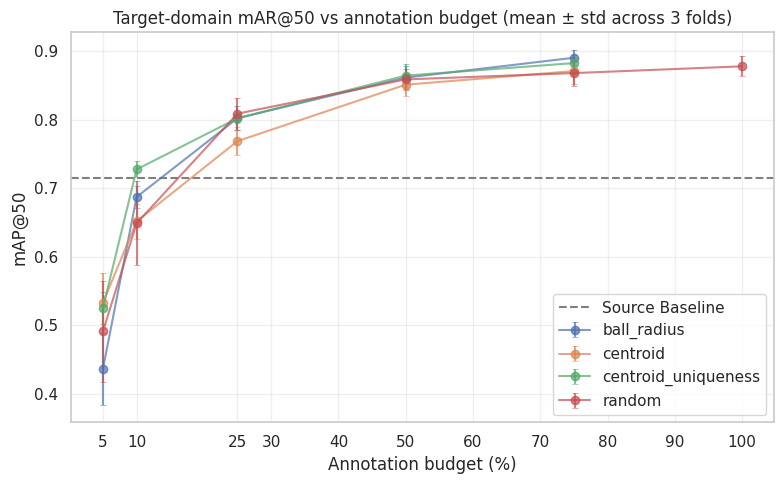

In [119]:
import matplotlib.pyplot as plt

fine = df_join.loc[df_join["method"] != "baseline"].copy()
fine=fine.loc[fine["partition_pct"]!=40]
agg = fine.groupby(["method", "partition_pct"])["mAR_50"].agg(["mean", "std"]).reset_index()

baseline_mean = baseline_df["mAR_50"].mean()

fig, ax = plt.subplots(figsize=(8, 5))
for method, g in agg.groupby("method"):
    g = g.sort_values("partition_pct")
    ax.errorbar(g["partition_pct"], g["mean"], yerr=g["std"]/3,
                 marker="o", capsize=2,capthick=0.5, label=method, alpha=0.7)

ax.axhline(baseline_mean, ls="--", color="gray", label=f"Source Baseline")
ax.set_xlabel("Annotation budget (%)")
ax.set_xticks([5,10,25,30,40,50,60,70,80,90,100])
ax.set_ylabel("mAP@50")
ax.set_title("Target-domain mAR@50 vs annotation budget (mean ± std across 3 folds)")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

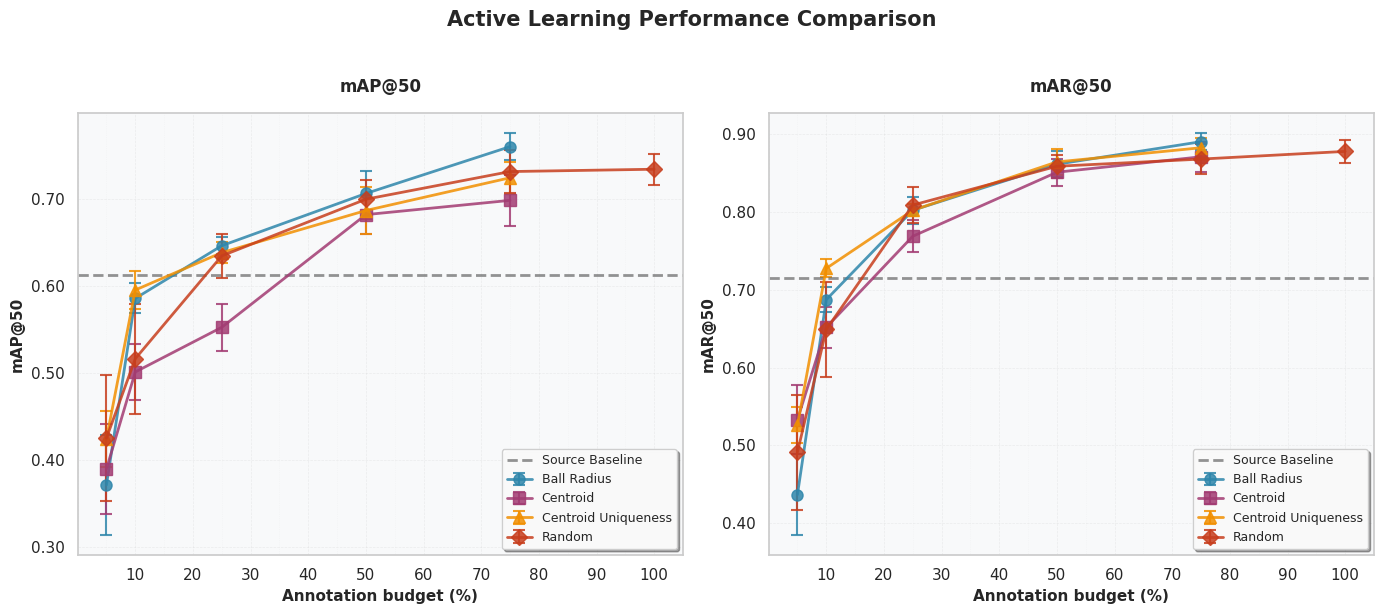

In [128]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import matplotlib.ticker as ticker

# Assuming df_join and baseline_df are already defined
fine = df_join.loc[df_join["method"] != "baseline"].copy()
fine = fine.loc[fine["partition_pct"] != 40]

# Aggregate for both metrics
agg_map = fine.groupby(["method", "partition_pct"])["mAP_50"].agg(["mean", "std"]).reset_index()
agg_mar = fine.groupby(["method", "partition_pct"])["mAR_50"].agg(["mean", "std"]).reset_index()

baseline_map_mean = baseline_df["mAP_50"].mean()
baseline_mar_mean = baseline_df["mAR_50"].mean()

# Create figure with two subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6), sharey=False)

# Color palette for methods
colors = {
    'ball_radius': '#2E86AB',
    'centroid': '#A23B72',
    'centroid_uniqueness': '#F18F01',
    'random': '#C73E1D'
}

markers = {
    'ball_radius': 'o',
    'centroid': 's',
    'centroid_uniqueness': '^',
    'random': 'D'
}

# Helper function to plot
def plot_metric(ax, agg_data, baseline_mean, metric_name, ylabel, title):
    for method, g in agg_data.groupby("method"):
        g = g.sort_values("partition_pct")
        ax.errorbar(g["partition_pct"], g["mean"], 
                   yerr=g["std"]/3,
                   marker=markers.get(method, 'o'), 
                   markersize=8,
                   linestyle='-',
                   linewidth=2,
                   capsize=4,
                   capthick=1.5,
                   elinewidth=1.5,
                   label=method.title().replace('_', ' '),
                   color=colors.get(method, None),
                   alpha=0.85)
    
    # Baseline
    ax.axhline(baseline_mean, ls='--', color='#666666', 
               linewidth=2, alpha=0.7, label='Source Baseline')
    
    # Styling
    ax.set_xlabel("Annotation budget (%)", fontsize=11, fontweight='bold')
    ax.set_ylabel(ylabel, fontsize=11, fontweight='bold')
    ax.set_title(title, fontsize=12, fontweight='bold', pad=15)
    
    # Set x-axis limits
    ax.set_xlim(0, 105)
    
    # Major ticks every 10
    ax.set_xticks(np.arange(0, 101, 10))
    ax.set_xticklabels([f'{x}' if x > 0 else '' for x in np.arange(0, 101, 10)])
    
    # Minor ticks every 5
    ax.set_xticks(np.arange(0, 101, 5), minor=True)
    
    # Grid with better styling
    ax.grid(True, linestyle='--', alpha=0.3, linewidth=0.5)
    ax.grid(True, which='minor', linestyle=':', alpha=0.15, linewidth=0.5)
    ax.set_axisbelow(True)
    
    # Y-axis formatting
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.2f}'))
    
    # Legend
    ax.legend(loc='lower right', frameon=True, fancybox=True, 
              shadow=True, framealpha=0.95, fontsize=9)
    
    # Add subtle background
    ax.set_facecolor('#f8f9fa')

# Plot mAP50
plot_metric(ax1, agg_map, baseline_map_mean, 'mAP_50', 
            'mAP@50', 'mAP@50')

# Plot mAR50  
plot_metric(ax2, agg_mar, baseline_mar_mean, 'mAR_50',
            'mAR@50', 'mAR@50')

# Adjust layout
plt.suptitle('Active Learning Performance Comparison', 
             fontsize=15, fontweight='bold', y=1.02)

# Add tight layout
plt.tight_layout()

fig.savefig("/share/home/e2406743/code/Dugongs_IRISA-MARBEC-LIRMM/chapter3/models_run/ready_plots/aclr_comparison.pdf",
            format='pdf',
            bbox_inches='tight')
# Show the plot
plt.show()



findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because

findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because

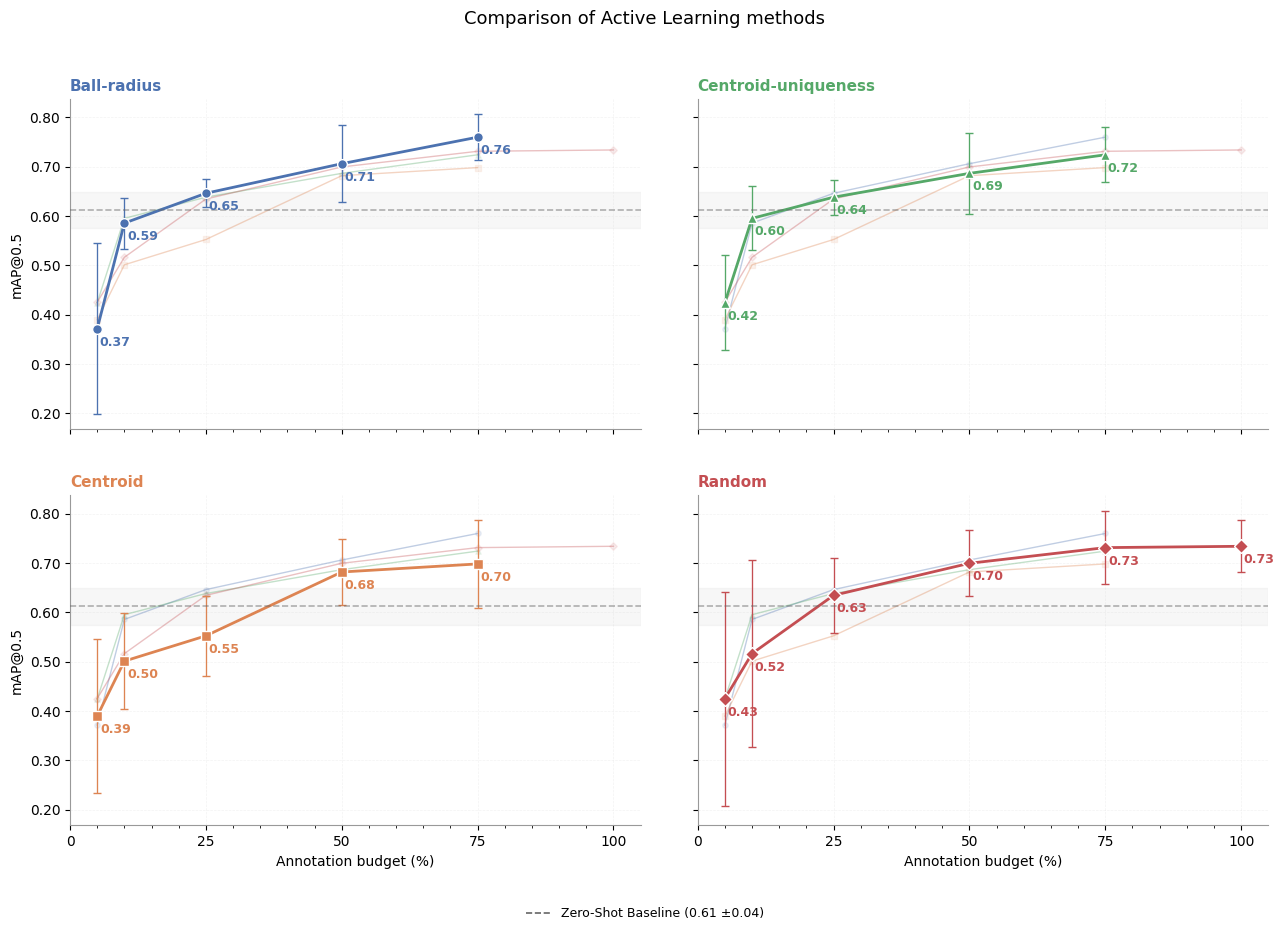

In [76]:
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import matplotlib.font_manager as fm

# Set a cleaner font
plt.rcParams['font.sans-serif'] = ['Arial']
plt.rcParams['font.size'] = 10

fine = df_join.loc[df_join["method"] != "baseline"].copy()
fine = fine.loc[fine["partition_pct"] != 40]

agg = (fine.groupby(["method", "partition_pct"])["mAP_50"]
            .agg(mean="mean", sd="std", n="count").reset_index())
agg["se"] = agg["sd"] / np.sqrt(agg["n"])

base_mu = baseline_df["mAP_50"].mean()
base_sd = baseline_df["mAP_50"].std()

# ── Updated color palette (softer, more harmonious) ──────────────
STYLE = {
    "ball_radius":         ("#4C72B0", "o", "Ball-radius"),      # Blue
    "centroid":            ("#DD8452", "s", "Centroid"),                 # Orange
    "centroid_uniqueness": ("#55A868", "^", "Centroid-uniqueness"),      # Green
    "random":              ("#C44E52", "D", "Random"),                   # Red
}
ORDER = ["ball_radius", "centroid_uniqueness", "centroid", "random"]
ERR = "sd"
ERR_LABEL = {"sd": "±1 SD", "se": "±1 SE"}[ERR]

fig, axes = plt.subplots(2, 2, figsize=(13, 9.5), sharex=True, sharey=True)

for ax, m in zip(axes.flat, ORDER):
    c, mk, lab = STYLE[m]

    # ── Other methods: faded but with their actual colors ────────────────
    for other in ORDER:
        if other == m:
            continue
        oc, omk, olab = STYLE[other]
        go = agg[agg.method == other].sort_values("partition_pct")
        ax.plot(go.partition_pct, go["mean"], color=oc,
                lw=1.0, alpha=0.35, zorder=1, label='_nolegend_')
        # Optional: add faint markers
        ax.scatter(go.partition_pct, go["mean"], 
                   marker=omk, s=15, color=oc, alpha=0.10, zorder=1)

    # ── Baseline band (thinner, more subtle) ─────────────────────────────
    ax.axhspan(base_mu - base_sd, base_mu + base_sd, 
               color="#999999", alpha=0.08, zorder=0)
    ax.axhline(base_mu, ls="--", color="#666666", lw=1.2, alpha=0.5, zorder=5)

    # ── Highlighted method (thinner error bars) ──────────────────────────
    g = agg[agg.method == m].sort_values("partition_pct")
    ax.errorbar(g.partition_pct, g["mean"], yerr=g[ERR],
                marker=mk, ms=7, mec="white", mew=1.0,
                lw=2.0, capsize=3, capthick=1.0, elinewidth=0.95,
                color=c, zorder=4, label='_nolegend_')

    # ── Mean value beside each point (cleaner) ─────────────────────────
    for _, r in g.iterrows():
        ax.annotate(f"{r['mean']:.2f}",
                    xy=(r.partition_pct, r["mean"]),
                    xytext=(13, -12), textcoords="offset points",
                    fontsize=9, color=c, fontweight="bold", zorder=5, ha='center')

    # ── Panel title and stats ──────────────────────────────────────────────
    at_max = g.iloc[-1]
    ax.set_title(f"{lab}", fontsize=11, loc="left", pad=6, 
                 color=c, fontweight="semibold")
    # ax.annotate(f"max {at_max['mean']:.2f} @ {int(at_max.partition_pct)}%   "
    #             f"(Δ = {at_max['mean']-base_mu:+.2f})",
    #             xy=(0.02, 0.93), xycoords="axes fraction",
    #             fontsize=8, color="#555555", style="normal")

    ax.grid(True, ls="--", alpha=0.15, lw=0.5)
    ax.set_axisbelow(True)
    for s in ("top", "right"):
        ax.spines[s].set_visible(False)
    # Lighten the spine colors
    for s in ("bottom", "left"):
        ax.spines[s].set_color("#999999")
        ax.spines[s].set_linewidth(0.8)

axes[0, 0].set_xlim(0, 105)
axes[0, 0].set_xticks(np.arange(0, 101, 25))
axes[0, 0].set_xticks(np.arange(0, 101, 5), minor=True)
axes[0, 0].yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.2f}"))

for ax in axes[1, :]:
    ax.set_xlabel("Annotation budget (%)", fontsize=10)
for ax in axes[:, 0]:
    ax.set_ylabel("mAP@0.5", fontsize=10)

# ── Shared legend (clean, no frame) ──────────────────────────────────────
from matplotlib.patches import Patch
legend_elements = [
    #Line2D([0], [0], color="#B0B0B0", lw=0.8, alpha=0.4, 
    #       label="Other methods (faded)"),
    Line2D([0], [0], color="#666666", ls="--", lw=1.2,
           label=f"Zero-Shot Baseline ({base_mu:.2f} ±{base_sd:.2f})"),
    #Patch(facecolor="#999999", alpha=0.08, label="±1 SD baseline")
]

fig.legend(handles=legend_elements,
           loc="lower center", bbox_to_anchor=(0.5, -0.02), 
           ncol=3, frameon=False, fontsize=9)

# ── Main title (cleaner) ────────────────────────────────────────────────────
fig.suptitle("Comparison of Active Learning methods\n",
             fontsize=13, y=0.95, fontweight="normal")

fig.tight_layout(rect=[0, 0.03, 1, 0.95])
fig.subplots_adjust(hspace=0.2, wspace=0.1)

fig.savefig("/share/home/e2406743/code/Dugongs_IRISA-MARBEC-LIRMM/chapter3/"
            "models_run/ready_plots/aclr_map50_facets.pdf",
            format="pdf", 
            bbox_inches="tight"
            )

In [13]:
df_join.columns

Index(['method', 'partition', 'partition_pct', 'seed', 'pred_field',
       'eval_key', 'mAP_50', 'mAP_50_95', 'mAR', 'mAR_50', 'f1', 'precision',
       'recall', 'f1_threshold', 'tp', 'fp', 'fn', 'n_gt', 'iou',
       'positive_label', 'status'],
      dtype='str')

In [82]:
df_join['n_gt'].unique()

array([142, 113, 108])

/tmp/ipykernel_2987145/1974046789.py:203: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


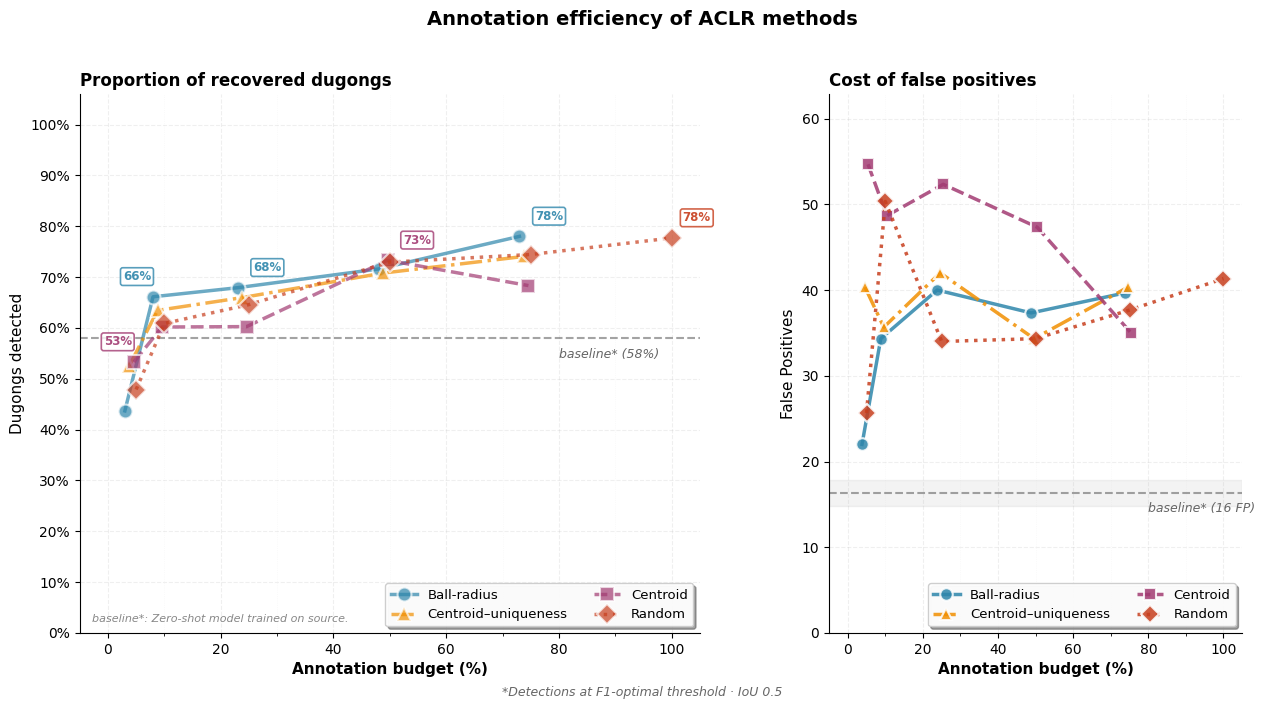

In [5]:
import numpy as np
import matplotlib.pyplot as plt

# Prepare data (your existing data preparation code remains the same)
fine = df_join[(df_join.status=="ok") & (df_join.method!="baseline")].copy()
fine = fine[fine.partition_pct != 40]
fine["frac"] = fine["tp"] / fine["n_gt"]

agg = (fine.groupby(["method","partition_pct"])
            .agg(frac=("frac","mean"), frac_sd=("frac","std"),
                 tp=("tp","mean"), fp=("fp","mean"), n=("frac","count"))
            .reset_index())

base = (baseline_df["tp"] / baseline_df["n_gt"])
base_mu, base_sd = base.mean(), base.std()

# Calculate baseline false positives
# Assuming baseline_df has 'fp' column for false positives
base_fp = baseline_df["fp"].mean() if "fp" in baseline_df.columns else 0
base_fp_sd = baseline_df["fp"].std() if "fp" in baseline_df.columns else 0

# Updated style with better visibility
STYLE = {
    "ball_radius": ("#2E86AB", "o", "Ball-radius", "-"),
    "centroid": ("#A23B72", "s", "Centroid", "--"),
    "centroid_uniqueness": ("#F18F01", "^", "Centroid–uniqueness", "-."),
    "random": ("#C73E1D", "D", "Random", ":")
}
ORDER = ["ball_radius", "centroid_uniqueness", "centroid", "random"]

# Create figure with better spacing
fig = plt.figure(figsize=(15, 7))
gs = fig.add_gridspec(1, 2, width_ratios=[1.5, 1], wspace=0.25)
ax = fig.add_subplot(gs[0])
axf = fig.add_subplot(gs[1])

# --- Left plot: Recall with cleaner design (NO ERROR BARS) ---
# Baseline with muted colors (removed 100% line)
# ax.axhspan(base_mu-base_sd, base_mu+base_sd, color="#666666", alpha=0.08, zorder=0)
ax.axhline(base_mu, ls="--", lw=1.5, color="#666666", alpha=0.6)
ax.annotate(f"baseline* ({base_mu:.0%})", 
            xy=(80, base_mu), xytext=(0, -14),
            textcoords="offset points", fontsize=9, color="#666666", style="italic")

# Store plotted data for annotation
plot_data = {}

# Plot each method - WITHOUT ERROR BARS
for i, m in enumerate(ORDER):
    g = agg[agg.method==m].sort_values("partition_pct")
    c, mk, lab, ls = STYLE[m]
    
    # Slight horizontal offset for overlapping points
    offset = (i - 2.5) * 0.8 if i < 3 else 0
    
    # Store data for finding max
    plot_data[m] = g
    
    # Simple line plot without error bars
    ax.plot(g.partition_pct + offset, g.frac, 
            marker=mk, ms=10,
            mec="white", mew=1.5, 
            lw=2.5,
            color=c, label=lab, 
            zorder=3, alpha=0.70,
            linestyle=ls)

# --- Find and annotate the best method at each partition ---
# Get unique partition values
partitions = agg['partition_pct'].unique()
partitions = sorted(partitions)

# For each partition, find the method with highest recall
for pct in partitions:
    best_method = None
    best_recall = -1
    
    for m in ORDER:
        g = plot_data[m]
        row = g[g.partition_pct == pct]
        if not row.empty:
            recall = row['frac'].values[0]
            if recall > best_recall:
                best_recall = recall
                best_method = m
    
    # Annotate only the best method for this partition
    if best_method is not None:
        g = plot_data[best_method]
        row = g[g.partition_pct == pct]
        c, mk, lab, ls = STYLE[best_method]
        
        # Calculate offset for this method
        i = ORDER.index(best_method)
        offset = (i - 1.5) * 0.8 if i < 3 else 0
        
        # Add annotation with a subtle background
        ax.annotate(f"{best_recall:.0%}", 
                   (pct + offset, best_recall), 
                   xytext=(-25 if pct<15 else 8, 12),  # Alternate direction
                   textcoords="offset points", 
                   fontsize=8.5, 
                   fontweight="bold",
                   color=c,
                   alpha=0.9,
                   bbox=dict(boxstyle="round,pad=0.2", 
                            facecolor="white", 
                            edgecolor=c, 
                            alpha=0.8,
                            linewidth=1.2))

# Add a small legend for the annotation style
ax.text(0.02, 0.02, "baseline*: Zero-shot model trained on source.", 
        transform=ax.transAxes, fontsize=8, 
        color="#555555", style="italic", alpha=0.7)

# Aesthetics
ax.set_ylim(0, 1.06)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.0%}"))
ax.set_ylabel("Dugongs detected", fontsize=11, fontweight="normal")
ax.set_title("Proportion of recovered dugongs", fontsize=12, loc="left", fontweight="bold")
ax.legend(loc="lower right", fontsize=9.5, framealpha=0.95, 
          fancybox=True, shadow=True, ncol=2)

# --- Right plot: False positives - WITH BASELINE ---

# Determine appropriate y-axis limits based on your data
# Get max FP across all methods to set ylim properly
max_fp = max(agg['fp'].max(), base_fp) * 1.15  # Include baseline in max calculation
min_fp = 0

# Add baseline for false positives
axf.axhline(base_fp, ls="--", lw=1.5, color="#666666", alpha=0.6, zorder=1)
axf.annotate(f"baseline* ({base_fp:.0f} FP)", 
            xy=(80, base_fp), xytext=(0, -14),
            textcoords="offset points", fontsize=9, color="#666666", style="italic")

# Optionally add a shaded band for baseline variability
if base_fp_sd > 0:
    axf.axhspan(base_fp - base_fp_sd, base_fp + base_fp_sd, 
                color="#666666", alpha=0.08, zorder=0)

# Plot each method
for i, m in enumerate(ORDER):
    g = agg[agg.method==m].sort_values("partition_pct")
    c, mk, lab, ls = STYLE[m]
    
    # Offset for overlapping points
    offset = (i - 1.5) * 0.8 if i < 3 else 0
    
    # Plot with explicit label for legend
    axf.plot(g.partition_pct + offset, g.fp, 
             marker=mk, ms=9, 
             mec="white", mew=1.5, 
             lw=2.5, color=c, alpha=0.85,
             linestyle=ls,
             label=lab)

# Set y-axis based on data range
axf.set_ylim(min_fp, max_fp)
axf.set_ylabel("False Positives", fontsize=11, fontweight="normal")
axf.set_title("Cost of false positives", fontsize=12, loc="left", fontweight="bold")
axf.legend(loc="lower right", fontsize=9.5, framealpha=0.95, 
           fancybox=True, shadow=True, ncol=2)

# --- Common formatting ---
for a in (ax, axf):
    a.set_xlabel("Annotation budget (%)", fontsize=11, fontweight="bold")
    a.set_xlim(-5, 105)
    
    # Major ticks every 20%
    a.set_xticks(np.arange(0, 101, 20))
    # Minor ticks every 10%
    a.set_xticks(np.arange(0, 101, 10), minor=True)
    
    # Y-axis ticks (different for each plot)
    if a == ax:
        # Left plot: y-axis ticks every 10%
        a.set_yticks(np.arange(0, 1.1, 0.1))
        a.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.0%}"))
    else:
        # Right plot: automatic y ticks based on data range
        a.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.0f}"))
    
    a.grid(ls="--", alpha=0.2, linewidth=0.8)
    a.grid(which='minor', ls=":", alpha=0.1, linewidth=0.5)  # Minor grid for x-axis
    a.set_axisbelow(True)
    for s in ("top","right"):
        a.spines[s].set_visible(False)
    a.tick_params(axis='both', which='major', labelsize=10)
    a.tick_params(axis='x', which='minor', labelsize=8)  # Smaller minor ticks

# Main title
fig.suptitle("Annotation efficiency of ACLR methods",
             fontsize=14, y=1.00, fontweight="bold")
fig.text(0.5, 0.02,  # x, y in figure coordinates (0-1)
         "*Detections at F1-optimal threshold · IoU 0.5", 
         ha='center',  # horizontal alignment
         fontsize=9, 
         color="#666666", 
         style="italic")

plt.tight_layout()
plt.show()

fig.savefig("/share/home/e2406743/code/Dugongs_IRISA-MARBEC-LIRMM/chapter3/"
            "models_run/ready_plots/aclr_cost_effective.pdf",
            format="pdf", 
            bbox_inches="tight"
            )

In [12]:
session = fo.launch_app(dataset,auto=False,port=5151)

Session launched. Run `session.show()` to open the App in a cell output.


In [131]:
d = df_join.loc[df_join['method']!='baseline']

/tmp/ipykernel_2491640/1700112024.py:44: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([f'{x}%' for x in data['partition_pct'].unique()])


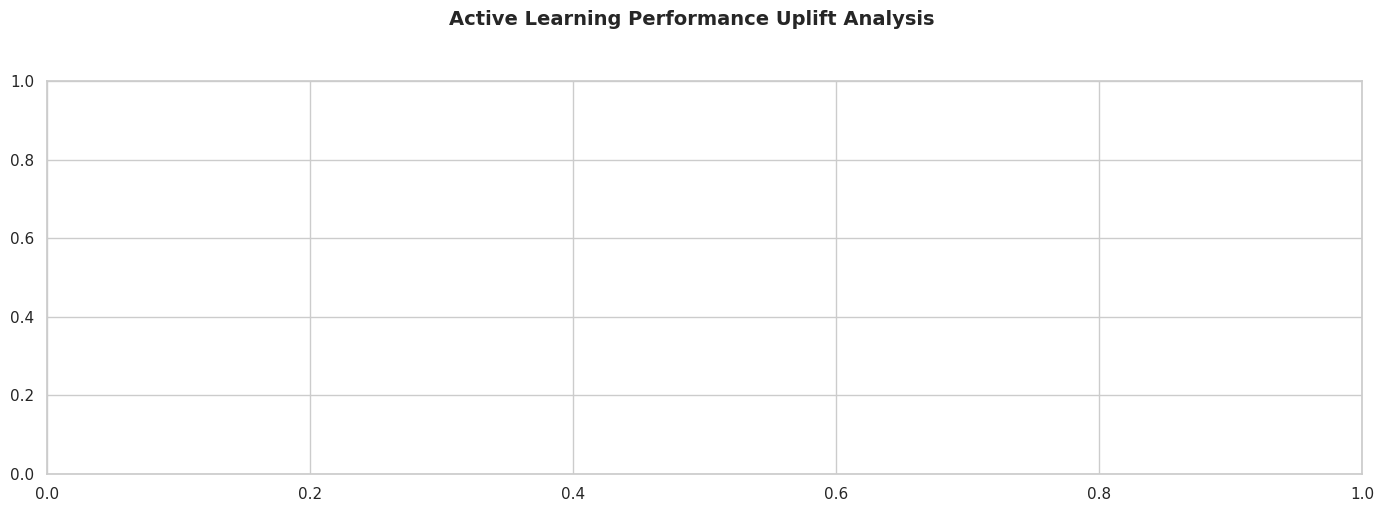

In [134]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# Assuming 'd' contains both 'mAR' and 'f1' columns
# Create pivots for both metrics

piv_f1 = d.pivot_table("f1", ["partition_pct", "seed"], "method")


upl_f1 = piv_f1.drop(columns="random").sub(piv_f1["random"], axis=0).reset_index()
upl_f1 = upl_f1.melt(["partition_pct", "seed"], var_name="method", value_name="uplift_f1")

# Merge the two metrics
upl = upl_f1

# Create figure with two subplots
fig, (ax1) = plt.subplots(1, 1, figsize=(14, 5))

# Color palette for methods (consistent with previous plots)
colors = {
    'ball_radius': '#2E86AB',
    'centroid': '#A23B72',
    'centroid_uniqueness': '#F18F01'
}

# Helper function to create bar plots
def plot_uplift(ax, data, metric_col, ylabel, title):
    # Create barplot
    sns.barplot(data=data, x="partition_pct", y=metric_col, hue="method",
                errorbar="sd", palette=colors, ax=ax,
                capsize=0.1, alpha=0.85,err_kws={'linewidth': 1.5})
    
    # Horizontal line at zero
    ax.axhline(0, color='black', linestyle='-', linewidth=1.5, alpha=0.8)
    
    # Styling
    ax.set_xlabel("Annotation budget (%)", fontsize=11, fontweight='bold')
    ax.set_ylabel(ylabel, fontsize=11, fontweight='bold')
    ax.set_title(title, fontsize=12, fontweight='bold', pad=15)
    
    # X-axis formatting
    ax.set_xticklabels([f'{x}%' for x in data['partition_pct'].unique()])
    
    # Y-axis formatting
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.2f}'))
    
    # Grid
    ax.grid(True, axis='y', linestyle='--', alpha=0.3, linewidth=0.5)
    ax.set_axisbelow(True)
    
    # Legend
    ax.legend(title='Method', title_fontsize=10, fontsize=9,
             loc='upper left', frameon=True, fancybox=True,
             shadow=True, framealpha=0.95)
    
    # Background
    ax.set_facecolor('#f8f9fa')
    
    # Add value labels on bars (optional - uncomment to use)
    # for container in ax.containers:
    #     ax.bar_label(container, fmt='%.2f', fontsize=8, padding=2)


# Plot F1 uplift
plot_uplift(ax2, upl, 'uplift_f1',
            'Δ F1 vs Random',
            'F1 Uplift over Random Selection')

# Add suptitle
plt.suptitle('Active Learning Performance Uplift Analysis', 
             fontsize=14, fontweight='bold', y=1.02)

plt.tight_layout()
plt.show()

KeyError: "The following id_vars or value_vars are not present in the DataFrame: ['uplift_mAR']"

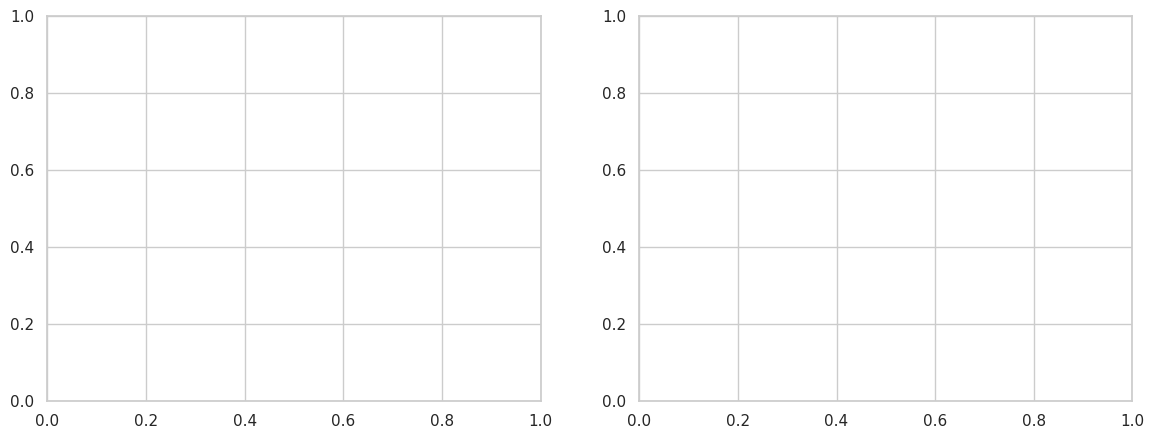

In [135]:
# Alternative: Combined view with subplot showing both metrics
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Bar chart showing both metrics side by side per method
# Reshape data for grouped bar chart
upl_long = upl.melt(['partition_pct', 'method'], 
                    ['uplift_mAR', 'uplift_f1'],
                    var_name='metric', value_name='uplift')
upl_long['metric'] = upl_long['metric'].map({'uplift_mAR': 'mAR@50', 
                                              'uplift_f1': 'F1'})

sns.barplot(data=upl_long, x='partition_pct', y='uplift', 
            hue='method', style='metric', 
            errorbar='sd', palette=colors, ax=axes[0],
            capsize=0.1, errwidth=1.5, alpha=0.85)
axes[0].axhline(0, color='black', lw=1.5)
axes[0].set_xlabel("Annotation budget (%)", fontsize=11, fontweight='bold')
axes[0].set_ylabel("Uplift vs Random", fontsize=11, fontweight='bold')
axes[0].set_title('Metric Comparison: mAR@50 vs F1', fontsize=12, fontweight='bold')
axes[0].legend(title='Method', fontsize=9)
axes[0].grid(True, axis='y', linestyle='--', alpha=0.3)

# Plot 2: Line plot showing trend more clearly
for method in upl['method'].unique():
    method_data = upl[upl['method'] == method].groupby('partition_pct')[['uplift_mAR', 'uplift_f1']].mean()
    axes[1].plot(method_data.index, method_data['uplift_mAR'], 
                marker='o', label=f'{method} (mAR)', 
                color=colors[method], linestyle='-', linewidth=2, markersize=6)
    axes[1].plot(method_data.index, method_data['uplift_f1'], 
                marker='s', label=f'{method} (F1)', 
                color=colors[method], linestyle='--', linewidth=2, markersize=6, alpha=0.6)

axes[1].axhline(0, color='black', lw=1.5)
axes[1].set_xlabel("Annotation budget (%)", fontsize=11, fontweight='bold')
axes[1].set_ylabel("Uplift vs Random", fontsize=11, fontweight='bold')
axes[1].set_title('Trend Analysis: mAR@50 vs F1', fontsize=12, fontweight='bold')
axes[1].grid(True, linestyle='--', alpha=0.3)
axes[1].legend(loc='best', fontsize=8, ncol=2)

plt.tight_layout()
plt.show()

Text(0.5, 1.0, 'Active-learning uplift over random selection')

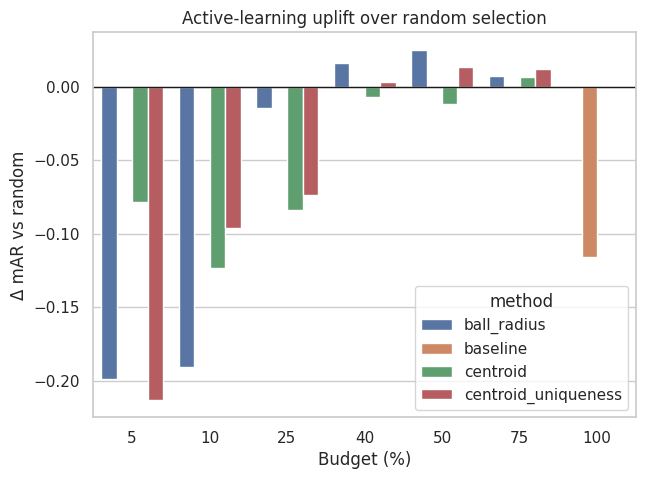

In [77]:
piv = d.pivot_table("mAR", ["partition_pct","seed"], "method")
upl = piv.drop(columns="random").sub(piv["random"], axis=0).reset_index()
upl = upl.melt(["partition_pct","seed"], var_name="method", value_name="uplift")

fig, ax = plt.subplots(figsize=(7,5))
sns.barplot(data=upl, x="partition_pct", y="uplift", hue="method",
            errorbar="sd", ax=ax)
ax.axhline(0, color="k", lw=1)
ax.set_xlabel("Budget (%)"); ax.set_ylabel("Δ mAR vs random")
ax.set_title("Active-learning uplift over random selection")

In [95]:
d = df_join.loc[df_join['method']=='baseline'
        ]
d

,method,partition,partition_pct,seed,pred_field,eval_key,mAP_50,mAP_50_95,mAR,mAR_50,...,precision,recall,f1_threshold,tp,fp,fn,n_gt,iou,positive_label,status
25,baseline,1.0,100,1,baseline_test1,baseline_seed1,0.569191,0.372370,0.450000,0.640845,...,0.826087,0.535211,0.088794,76,16,66,142,0.5,[np.str_('dugong')],ok
25,baseline,1.0,100,2,baseline_test2,baseline_seed2,0.634092,0.367137,0.497345,0.734513,...,0.797753,0.628319,0.093719,71,18,42,113,0.5,[np.str_('dugong')],ok
25,baseline,1.0,100,3,baseline_test3,baseline_seed3,0.633252,0.458222,0.579630,0.768519,...,0.805195,0.574074,0.098643,62,15,46,108,0.5,[np.str_('dugong')],ok


Text(0.5, 1.0, 'Precision–recall at F1-optimal threshold')

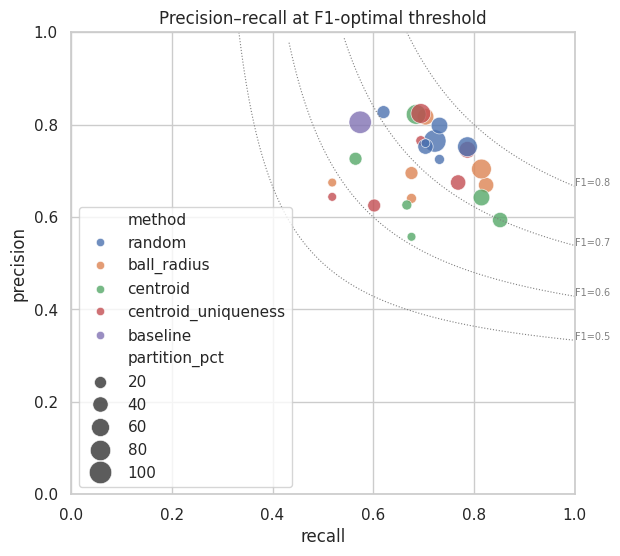

In [78]:
fig, ax = plt.subplots(figsize=(6.5,6))
sns.scatterplot(data=d, 
                x="recall", 
                y="precision", 
                hue="method",
                size="partition_pct", 
                sizes=(40,260), 
                alpha=.8, 
                ax=ax
                )
for f in [0.5,0.6,0.7,0.8]:                      # iso-F1 contours
    r = np.linspace(0.01,1,200); p = f*r/(2*r-f)
    m = (p>0)&(p<=1); ax.plot(r[m], p[m], ls=":", c="grey", lw=.8)
    if m.any(): ax.annotate(f"F1={f}", (r[m][-1], p[m][-1]), fontsize=7, color="grey")
ax.set_xlim(0,1); ax.set_ylim(0,1); ax.set_title("Precision–recall at F1-optimal threshold")

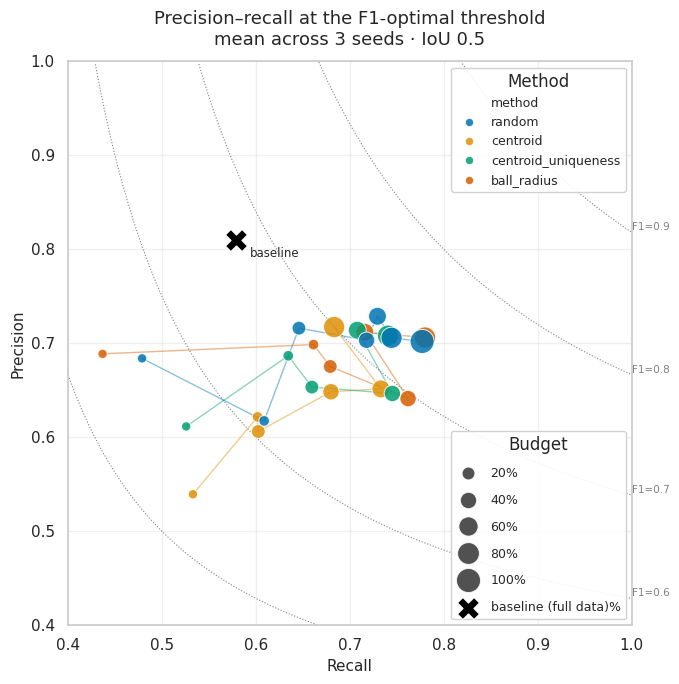

In [79]:
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

d = df_join[df_join.status == "ok"].copy()

order   = ["random", "centroid", "centroid_uniqueness", "ball_radius"]
palette = dict(zip(order, sns.color_palette("colorblind", len(order))))

# ── mean across seeds, per (method, budget) ──────────────────────────────────
agg = (d.groupby(["method", "partition_pct"], as_index=False)
         .agg(precision=("precision", "mean"),
              recall=("recall", "mean"),
              n_seeds=("seed", "nunique")))

al   = agg[agg.method.isin(order)]
base = agg[agg.method == "baseline"]

sns.set_theme(style="whitegrid", context="notebook")
fig, ax = plt.subplots(figsize=(7.5, 7))

# ── iso-F1 contours first, so points sit on top ──────────────────────────────
for f in [0.4, 0.5, 0.6, 0.7, 0.8, 0.9]:
    r = np.linspace(0.001, 1, 400)
    p = f * r / (2 * r - f)
    m = (p > 0) & (p <= 1) & (r >= f / 2)
    if not m.any():
        continue
    ax.plot(r[m], p[m], ls=":", c="grey", lw=.8, zorder=1)
    ax.annotate(f"F1={f}", (r[m][-1], p[m][-1]), fontsize=7.5, color="grey",
                ha="left", va="bottom", zorder=1)

# ── AL methods: dot size = budget ────────────────────────────────────────────
sns.scatterplot(data=al, x="recall", y="precision", hue="method",
                size="partition_pct", sizes=(45, 300),
                hue_order=order, palette=palette,
                alpha=.85, edgecolor="white", linewidth=.7,
                ax=ax, zorder=3)

# connect each method's points in budget order -> shows the trajectory
for meth, g in al.sort_values("partition_pct").groupby("method"):
    ax.plot(g.recall, g.precision, color=palette[meth],
            lw=1.0, alpha=.45, zorder=2)

# ── baseline: X marker ───────────────────────────────────────────────────────
if len(base):
    ax.scatter(base.recall, base.precision, marker="X", s=260,
               c="black", edgecolor="white", linewidth=1.0,
               zorder=5, label="baseline (full data)")
    for _, r_ in base.iterrows():
        ax.annotate("baseline", (r_.recall, r_.precision),
                    textcoords="offset points", xytext=(10, -12),
                    fontsize=8.5, fontweight="medium", zorder=5)

# ── legend: split method vs budget ───────────────────────────────────────────
h, l = ax.get_legend_handles_labels()
cut = l.index("partition_pct") if "partition_pct" in l else len(l)
leg1 = ax.legend(h[:cut], l[:cut], title="Method", 
                 loc="upper right", frameon=True, framealpha=.9, fontsize=9)
ax.add_artist(leg1)
if cut < len(l):
    ax.legend(h[cut+1:], [f"{v}%" for v in l[cut+1:]], title="Budget",
              loc="lower right", frameon=True, framealpha=.9,
              fontsize=9, labelspacing=1.1)

ax.set_xlabel("Recall", fontsize=11)
ax.set_ylabel("Precision", fontsize=11)
ax.set_title("Precision–recall at the F1-optimal threshold\n"
             f"mean across {int(agg.n_seeds.max())} seeds · IoU 0.5",
             fontsize=13, pad=12)
ax.set_aspect("equal")
ax.grid(alpha=.3)

# zoom to the populated region (comment out for the full unit square)
pad = .06
ax.set_xlim(0.4, 1.0)
ax.set_ylim(0.4, 1.0)

fig.tight_layout()
# fig.savefig("pr_operating_points.png", dpi=300, bbox_inches="tight")